<a href="https://colab.research.google.com/github/twillixa/PPS/blob/main/Main_1_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from pulp import (
    LpProblem, LpMinimize, LpVariable, LpInteger,
    lpSum, value, PULP_CBC_CMD
)

##Data loading

In [2]:





REPO_URL = "https://github.com/twillixa/PPS"
CSV_FILENAME = "Demand_data.csv"
RAW_URL = f"https://raw.githubusercontent.com/twillixa/PPS/main/{CSV_FILENAME}"

demand_df = pd.read_csv(RAW_URL)
demand_df.columns = [
    "Day",
    "3235 Movement",
    "Oystersteel Case",
    "Sapphire Crystal",
    "Jubilee Bracelet",
    "Lubricant Oil",
    "Diamond Marker",
    "Gold Crown",
]

component_names = [c for c in demand_df.columns if c != "Day"]

# Per-component summary statistics (daily)
demand_stats = {}
for comp in component_names:
    series = demand_df[comp]
    demand_stats[comp] = {
        "mean_daily": round(series.mean(), 4),
        "std_daily":  round(series.std(ddof=1), 4),
        "min_daily":  int(series.min()),
        "max_daily":  int(series.max()),
        "total":      int(series.sum()),
    }

print(f"Loaded '{CSV_FILENAME}' from {REPO_URL}")
print(f"{len(demand_df)} days, {len(component_names)} components\n")
print(f"  {'Component':<20} {'Mean/day':>9} {'Std/day':>9} {'Min':>5} {'Max':>5} {'Total':>7}")
print(f"  {'-'*58}")
for comp, s in demand_stats.items():
    print(f"  {comp:<20} {s['mean_daily']:>9.2f} {s['std_daily']:>9.2f} "
          f"{s['min_daily']:>5} {s['max_daily']:>5} {s['total']:>7}")

Loaded 'Demand_data.csv' from https://github.com/twillixa/PPS
365 days, 7 components

  Component             Mean/day   Std/day   Min   Max   Total
  ----------------------------------------------------------
  3235 Movement            14.26      3.56     5    25    5205
  Oystersteel Case         15.18      4.28     4    29    5540
  Sapphire Crystal         14.21      3.59     4    25    5187
  Jubilee Bracelet          8.02      0.99     5    12    2926
  Lubricant Oil           150.72     41.18    40   298   55014
  Diamond Marker           47.81      5.09    35    63   17449
  Gold Crown                8.01      3.03     0    17    2922


In [3]:

# ------------------------------------------------------------
# AGGREGATE PLANNING PARAMETERS (Table 1)
# ------------------------------------------------------------

planning_horizon = 12  # months (January to December)

# Workforce & Production
initial_workers = 90          # workers at start of January
production_rate = 10          # watches per worker per month

# Inventory
starting_inventory = 900      # watches (beginning of January)
ending_inventory_target = 1000  # watches (end of December)
holding_cost = 1000           # CHF per watch per month

# Labor Costs
regular_wage = 7000           # CHF per worker per month
hiring_cost = 50000           # CHF per worker hired
layoff_cost = 25000           # CHF per worker laid off

# Overtime
overtime_allowance = 0.20     # up to 20% extra capacity
overtime_cost_multiplier = 2  # 2x regular wage
overtime_months = [3, 5, 9, 12]  # March, May, September, December

# Subcontracting
subcontracting_limit = 300    # watches per month (max)
subcontracting_cost = 15000   # CHF per watch
subcontracting_months = [6, 7, 10, 12]  # June, July, October, December

# Derived: overtime cost per worker per month (when overtime is used)
overtime_cost_per_worker = regular_wage * overtime_cost_multiplier  # CHF

# ------------------------------------------------------------
# FORECASTED MONTHLY DEMAND (Table 2)
# ------------------------------------------------------------

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

demand = {
    "Jan": 900,
    "Feb": 950,
    "Mar": 1200,
    "Apr": 1050,
    "May": 1100,
    "Jun": 1300,
    "Jul": 1250,
    "Aug": 1100,
    "Sep": 1300,
    "Oct": 1450,
    "Nov": 1500,
    "Dec": 1700,
}

demand_list = [demand[m] for m in months]
total_annual_demand = sum(demand_list)  # total watches needed

# ------------------------------------------------------------
# INVENTORY MANAGEMENT PARAMETERS (Table 3, week 4 slide 19)
# ------------------------------------------------------------
# Components for Aurelius SA watches
# Keys: lead_time (days), holding_cost (CHF/unit/month),
#       ordering_cost (CHF), shelf_life (days), supplier

components = {
    "3235 Movement": {
        "lead_time_days": 60,
        "holding_cost_per_unit_month": 1200,  # CHF/unit/month
        "ordering_cost": 9000,                # CHF per order
        "shelf_life_days": 365,
        "supplier": "Supplier",
    },
    "Oystersteel Case": {
        "lead_time_days": 45,
        "holding_cost_per_unit_month": 400,
        "ordering_cost": 7000,
        "shelf_life_days": 505,
        "supplier": "Internal",
    },
    "Sapphire Crystal": {
        "lead_time_days": 30,
        "holding_cost_per_unit_month": 200,
        "ordering_cost": 4000,
        "shelf_life_days": 365,
        "supplier": "Internal",
    },
    "Jubilee Bracelet": {
        "lead_time_days": 35,
        "holding_cost_per_unit_month": 220,
        "ordering_cost": 3500,
        "shelf_life_days": 1460,
        "supplier": "Internal",
    },
    "Lubricant Oil": {
        "lead_time_days": 14,
        "holding_cost_per_unit_month": 50,
        "ordering_cost": 1000,
        "shelf_life_days": 730,
        "supplier": "Supplier DE",
    },
    "Diamond Marker": {
        "lead_time_days": 21,
        "holding_cost_per_unit_month": 900,
        "ordering_cost": 6000,
        "shelf_life_days": 1825,
        "supplier": "Supplier CH",
    },
    "Gold Crown": {
        "lead_time_days": 40,
        "holding_cost_per_unit_month": 350,
        "ordering_cost": 5000,
        "shelf_life_days": 730,
        "supplier": "Supplier CH",
    },
}

# ------------------------------------------------------------
# SUMMARY PRINTOUT
# ------------------------------------------------------------

if __name__ == "__main__":
    print("=" * 55)
    print("AURELIUS SA — PROJECT PART 1 DATA SUMMARY")
    print("=" * 55)

    print("\n--- Aggregate Planning ---")
    print(f"  Planning horizon      : {planning_horizon} months")
    print(f"  Initial workers       : {initial_workers}")
    print(f"  Production rate       : {production_rate} watches/worker/month")
    print(f"  Starting inventory    : {starting_inventory} watches")
    print(f"  Ending target         : {ending_inventory_target} watches")
    print(f"  Holding cost          : {holding_cost} CHF/watch/month")
    print(f"  Regular wage          : {regular_wage} CHF/worker/month")
    print(f"  Hiring cost           : {hiring_cost} CHF/worker")
    print(f"  Layoff cost           : {layoff_cost} CHF/worker")
    print(f"  Overtime allowance    : {overtime_allowance*100:.0f}% extra capacity")
    print(f"  Overtime months       : {[months[m-1] for m in overtime_months]}")
    print(f"  Subcontracting limit  : {subcontracting_limit} watches/month")
    print(f"  Subcontracting cost   : {subcontracting_cost} CHF/watch")
    print(f"  Subcontracting months : {[months[m-1] for m in subcontracting_months]}")

    print("\n--- Monthly Demand Forecast ---")
    print(f"  {'Month':<6} {'Demand':>8}")
    print(f"  {'-'*16}")
    for m, d in demand.items():
        print(f"  {m:<6} {d:>8}")
    print(f"  {'-'*16}")
    print(f"  {'TOTAL':<6} {total_annual_demand:>8}")

    print("\n--- Inventory Components ---")
    print(f"  {'Component':<20} {'LT(d)':>6} {'Hold':>6} {'Order':>7} "
          f"{'Shelf(d)':>9} {'Supplier':<12}")
    print(f"  {'-'*65}")
    for name, p in components.items():
        print(f"  {name:<20} {p['lead_time_days']:>6} "
              f"{p['holding_cost_per_unit_month']:>6} "
              f"{p['ordering_cost']:>7} "
              f"{p['shelf_life_days']:>9} "
              f"{p['supplier']:<12}")

    print("\nData loaded successfully. Ready for analysis.")


AURELIUS SA — PROJECT PART 1 DATA SUMMARY

--- Aggregate Planning ---
  Planning horizon      : 12 months
  Initial workers       : 90
  Production rate       : 10 watches/worker/month
  Starting inventory    : 900 watches
  Ending target         : 1000 watches
  Holding cost          : 1000 CHF/watch/month
  Regular wage          : 7000 CHF/worker/month
  Hiring cost           : 50000 CHF/worker
  Layoff cost           : 25000 CHF/worker
  Overtime allowance    : 20% extra capacity
  Overtime months       : ['Mar', 'May', 'Sep', 'Dec']
  Subcontracting limit  : 300 watches/month
  Subcontracting cost   : 15000 CHF/watch
  Subcontracting months : ['Jun', 'Jul', 'Oct', 'Dec']

--- Monthly Demand Forecast ---
  Month    Demand
  ----------------
  Jan         900
  Feb         950
  Mar        1200
  Apr        1050
  May        1100
  Jun        1300
  Jul        1250
  Aug        1100
  Sep        1300
  Oct        1450
  Nov        1500
  Dec        1700
  ----------------
  TOTAL    

#**Part 1**

##Model 1

In [4]:
# ── Model 1: Base MILP(chase / level) ──────────────────

def solve_model1(strategy="level", verbose=False):
    """
    Model 1 – no overtime, no subcontracting.

    strategy : "level" → workforce is fixed to a single constant W*
                         production is forced to full capacity each month
               "chase" → workforce can change freely each month
                         production is capped but not forced to full capacity
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model1_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]
    P = [LpVariable(f"P_{t}", lowBound=0)                for t in range(T)]

    # chase: W[t] free each month  |  level: all W[t] forced equal via W_star
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T          # same variable reused → forces constant workforce
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker * W[t] for t in range(T))
      + lpSum(hiring_cost     * H[t] for t in range(T))
      + lpSum(layoff_cost     * F[t] for t in range(T))
      + lpSum(holding_cost    * I[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t],           f"workforce_{t}"
        # Inventory balance
        prob += I[t] == prev_I + P[t] - demand_list[t], f"inventory_{t}"

        if strategy == "level":
            # Force full capacity utilisation — production must equal max capacity
            prob += P[t] == prod_per_worker * W[t],      f"prod_cap_{t}"
        else:
            # Cap production at max capacity — solver can choose to produce less
            prob += P[t] <= prod_per_worker * W[t],      f"prod_cap_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t]))) for t in range(T)]
    hired     = [int(round(value(H[t]))) for t in range(T)]
    fired     = [int(round(value(F[t]))) for t in range(T)]
    inventory = [value(I[t])             for t in range(T)]

    wage_c   = [wage_per_worker * workers[t]   for t in range(T)]
    hire_c   = [hiring_cost     * hired[t]     for t in range(T)]
    layoff_c = [layoff_cost     * fired[t]     for t in range(T)]
    inv_c    = [holding_cost    * inventory[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Produced":       [value(P[t]) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total Inventory": sum(inv_c),
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(inv_c),
    }

    return df, summary

In [5]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

# Global variables used by solve_model1 (and all subsequent models)
T               = planning_horizon
I0              = starting_inventory
I_T             = ending_inventory_target
W0              = initial_workers
prod_per_worker = production_rate
wage_per_worker = regular_wage
# Note: hiring_cost, layoff_cost, holding_cost, subcontracting_cost already defined above
MONTH_NAMES     = months
demand_list     = [demand[m] for m in months]

for strat in ("level", "chase"):
    df, s = solve_model1(strategy=strat)
    print(f"\n{'\u2550'*60}")
    print(f"  MODEL 1 \u2013 {strat.upper()} STRATEGY")
    print(f"{'\u2550'*60}")
    display(df)
    print(f"\n\u2500\u2500 Cost Summary (CHF) \u2500\u2500")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")



════════════════════════════════════════════════════════════
  MODEL 1 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,125,35,0,"1,250",900,1250,875000,1750000,0,"1,250,000","3,875,000"
1,Feb,125,0,0,"1,250",950,1550,875000,0,0,"1,550,000","2,425,000"
2,Mar,125,0,0,"1,250",1200,1600,875000,0,0,"1,600,000","2,475,000"
3,Apr,125,0,0,"1,250",1050,1800,875000,0,0,"1,800,000","2,675,000"
4,May,125,0,0,"1,250",1100,1950,875000,0,0,"1,950,000","2,825,000"
5,Jun,125,0,0,"1,250",1300,1900,875000,0,0,"1,900,000","2,775,000"
6,Jul,125,0,0,"1,250",1250,1900,875000,0,0,"1,900,000","2,775,000"
7,Aug,125,0,0,"1,250",1100,2050,875000,0,0,"2,050,000","2,925,000"
8,Sep,125,0,0,"1,250",1300,2000,875000,0,0,"2,000,000","2,875,000"
9,Oct,125,0,0,"1,250",1450,1800,875000,0,0,"1,800,000","2,675,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,500,000
  Total Hiring        :       1,750,000
  Total Layoff        :               0
  Total Inventory     :      20,450,000
  Grand Total         :      32,700,000

════════════════════════════════════════════════════════════
  MODEL 1 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Produced,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,900,0,630000,0,0,0,"630,000"
1,Feb,100,10,0,"1,000",950,50,700000,500000,0,"50,000","1,250,000"
2,Mar,115,15,0,"1,150",1200,0,805000,750000,0,0,"1,555,000"
3,Apr,115,0,0,"1,050",1050,0,805000,0,0,0,"805,000"
4,May,115,0,0,"1,150",1100,50,805000,0,0,"50,000","855,000"
5,Jun,125,10,0,"1,250",1300,0,875000,500000,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",1250,0,875000,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",1100,0,875000,0,0,0,"875,000"
8,Sep,131,6,0,"1,310",1300,10,917000,300000,0,"10,000","1,227,000"
9,Oct,188,57,0,"1,880",1450,440,1316000,2850000,0,"440,000","4,606,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      11,235,000
  Total Hiring        :       4,900,000
  Total Layoff        :               0
  Total Inventory     :       2,370,000
  Grand Total         :      18,505,000


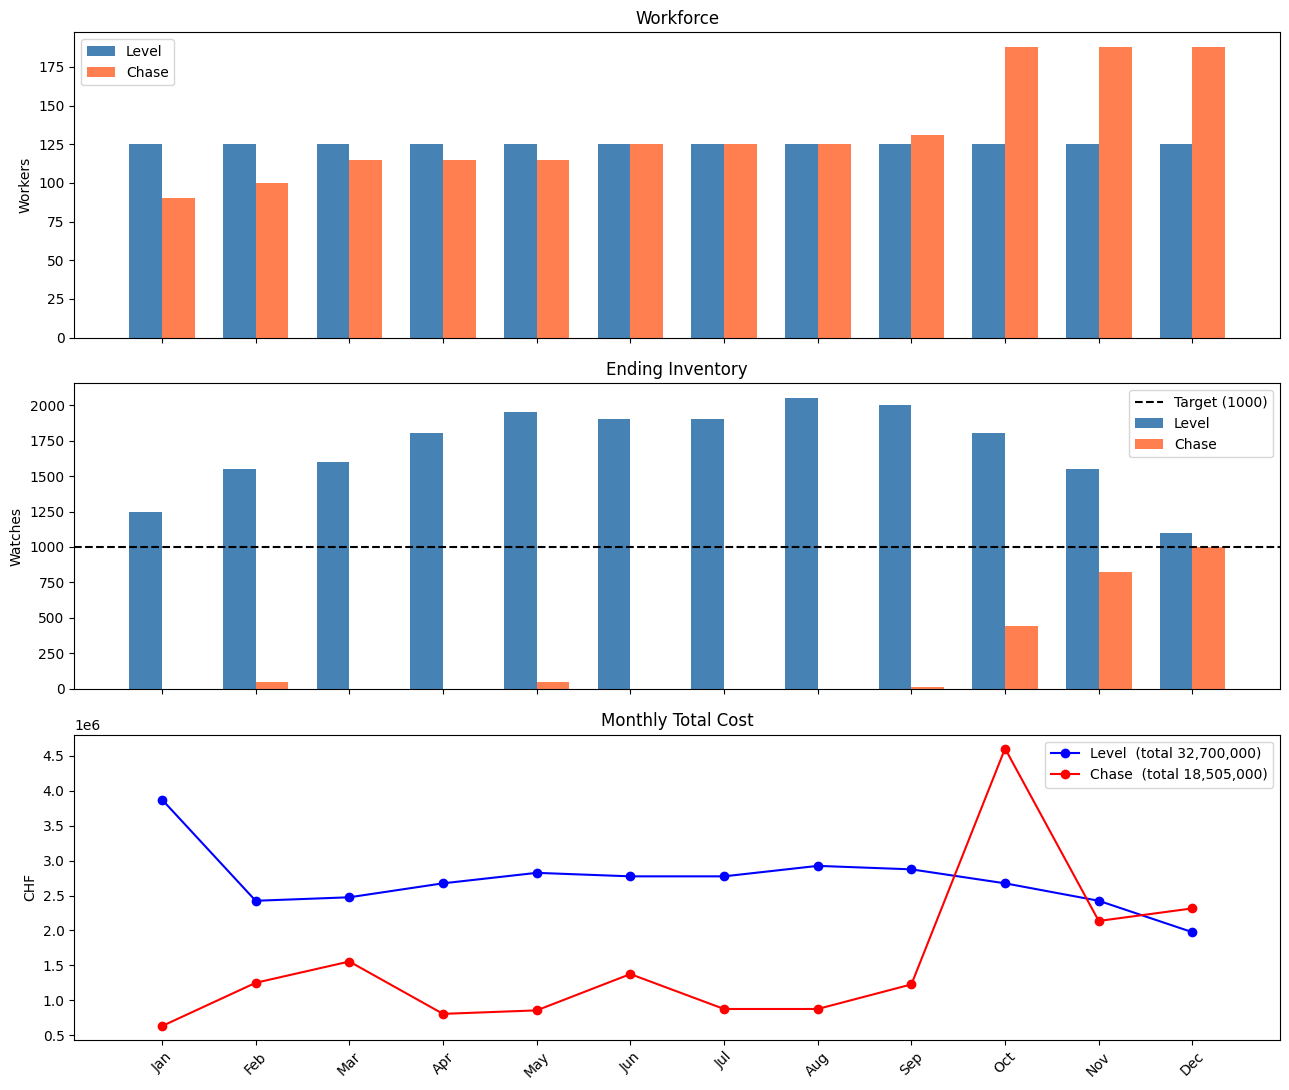

In [6]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model1(strategy="level")
df_chase, s_chase = solve_model1(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 2

In [7]:
# ── Model 2: MILP with overtime (chase / level) ───────────────────────────────

def solve_model2(strategy="level", verbose=False):
    """
    Model 2 – overtime allowed in Mar, May, Sep, Dec (no subcontracting).

    Decision variables:
        W[t]  : workforce at end of month t
        P[t]  : Production at month t
        H[t]  : workers hired at start of month t
        F[t]  : workers fired at start of month t
        I[t]  : ending inventory in month t
        OT[t] : overtime production in month t (watches, only in overtime months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model2_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H  = [LpVariable(f"H_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    F  = [LpVariable(f"F_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    I  = [LpVariable(f"I_{t}",  lowBound=0)                for t in range(T)]
    P  = [LpVariable(f"P_{t}", lowBound=0)                 for t in range(T)]
    OT = [LpVariable(f"OT_{t}", lowBound=0)                for t in range(T)]

    # ── Overtime cost: 2× regular wage, charged per extra watch produced ──────
    # Regular rate: prod_per_worker watches/worker/month → 1 watch costs wage/prod_per_worker
    # Overtime rate: 2× that
    ot_cost_per_watch = (wage_per_worker * overtime_cost_multiplier) / prod_per_worker

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker  * W[t]  for t in range(T))
      + lpSum(hiring_cost      * H[t]  for t in range(T))
      + lpSum(layoff_cost      * F[t]  for t in range(T))
      + lpSum(holding_cost     * I[t]  for t in range(T))
      + lpSum(ot_cost_per_watch * OT[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W = W0 if t == 0 else W[t-1]
        prev_I = I0 if t == 0 else I[t-1]
        month_num = t + 1   # months list is 0-indexed; overtime_months is 1-indexed

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t],  f"workforce_{t}"

        # Inventory balance (regular production + overtime)
        prob += (I[t] == prev_I + P[t] + OT[t] - demand_list[t],
                 f"inventory_{t}")

        # Overtime cap: up to overtime_allowance × regular capacity
        prob += OT[t] <= overtime_allowance * prod_per_worker * W[t], f"ot_cap_{t}"

        if strategy == "level":
            # Force full capacity utilisation — production must equal max capacity
            prob += P[t] == prod_per_worker * W[t],      f"prod_cap_{t}"
        else:
            # Cap production at max capacity — solver can choose to produce less
            prob += P[t] <= prod_per_worker * W[t],      f"prod_cap_{t}"

        # Overtime only allowed in designated months
        if month_num not in overtime_months:
            prob += OT[t] == 0, f"ot_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers   = [int(round(value(W[t])))  for t in range(T)]
    hired     = [int(round(value(H[t])))  for t in range(T)]
    fired     = [int(round(value(F[t])))  for t in range(T)]
    overtime  = [value(OT[t])             for t in range(T)]
    inventory = [value(I[t])              for t in range(T)]

    wage_c   = [wage_per_worker   * workers[t]              for t in range(T)]
    hire_c   = [hiring_cost       * hired[t]                for t in range(T)]
    layoff_c = [layoff_cost       * fired[t]                for t in range(T)]
    inv_c    = [holding_cost      * inventory[t]            for t in range(T)]
    ot_c     = [ot_cost_per_watch * overtime[t]             for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [value(P[t]) for t in range(T)],
        "OT Prod.":       [int(round(o)) for o in overtime],
        "Total Prod.":     [value(P[t]) + int(round(overtime[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "OT Cost":        ot_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+ot_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":        strategy,
        "Status":          prob.status,
        "Total Wage":      sum(wage_c),
        "Total Hiring":    sum(hire_c),
        "Total Layoff":    sum(layoff_c),
        "Total OT":        sum(ot_c),
        "Total Inventory": sum(inv_c),
        "Grand Total":     sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(ot_c)+sum(inv_c),
    }

    return df, summary

In [8]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model2(strategy=strat)
    print(f"\n{'═'*60}")
    print(f"  MODEL 2 – {strat.upper()} STRATEGY")
    print(f"{'═'*60}")
    display(df)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")


════════════════════════════════════════════════════════════
  MODEL 2 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,Inventory Cost,Total Cost
0,Jan,120,30,0,"1,200",0,"1,200",900,1200,840000,1500000,0,0,"1,200,000","3,540,000"
1,Feb,120,0,0,"1,200",0,"1,200",950,1450,840000,0,0,0,"1,450,000","2,290,000"
2,Mar,120,0,0,"1,200",0,"1,200",1200,1450,840000,0,0,0,"1,450,000","2,290,000"
3,Apr,120,0,0,"1,200",0,"1,200",1050,1600,840000,0,0,0,"1,600,000","2,440,000"
4,May,120,0,0,"1,200",20,"1,220",1100,1720,840000,0,0,"28,000","1,720,000","2,588,000"
5,Jun,120,0,0,"1,200",0,"1,200",1300,1620,840000,0,0,0,"1,620,000","2,460,000"
6,Jul,120,0,0,"1,200",0,"1,200",1250,1570,840000,0,0,0,"1,570,000","2,410,000"
7,Aug,120,0,0,"1,200",0,"1,200",1100,1670,840000,0,0,0,"1,670,000","2,510,000"
8,Sep,120,0,0,"1,200",240,"1,440",1300,1810,840000,0,0,"336,000","1,810,000","2,986,000"
9,Oct,120,0,0,"1,200",0,"1,200",1450,1560,840000,0,0,0,"1,560,000","2,400,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,080,000
  Total Hiring        :       1,500,000
  Total Layoff        :               0
  Total OT            :         700,000
  Total Inventory     :      17,910,000
  Grand Total         :      30,190,000

════════════════════════════════════════════════════════════
  MODEL 2 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,0,0,900,0,630000,0,0,0,0,"630,000"
1,Feb,95,5,0,950,0,950,950,0,665000,250000,0,0,0,"915,000"
2,Mar,105,10,0,"1,050",150,"1,200",1200,0,735000,500000,0,"210,000",0,"1,445,000"
3,Apr,105,0,0,"1,050",0,"1,050",1050,0,735000,0,0,0,0,"735,000"
4,May,115,10,0,"1,150",0,"1,150",1100,50,805000,500000,0,0,"50,000","1,355,000"
5,Jun,125,10,0,"1,250",0,"1,250",1300,0,875000,500000,0,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",0,"1,250",1250,0,875000,0,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",0,"1,100",1100,0,875000,0,0,0,0,"875,000"
8,Sep,132,7,0,"1,318",0,"1,318",1300,18,924000,350000,0,0,"18,000","1,292,000"
9,Oct,176,44,0,"1,760",0,"1,760",1450,328,1232000,2200000,0,0,"328,000","3,760,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,815,000
  Total Hiring        :       4,300,000
  Total Layoff        :               0
  Total OT            :         702,800
  Total Inventory     :       1,984,000
  Grand Total         :      17,801,800


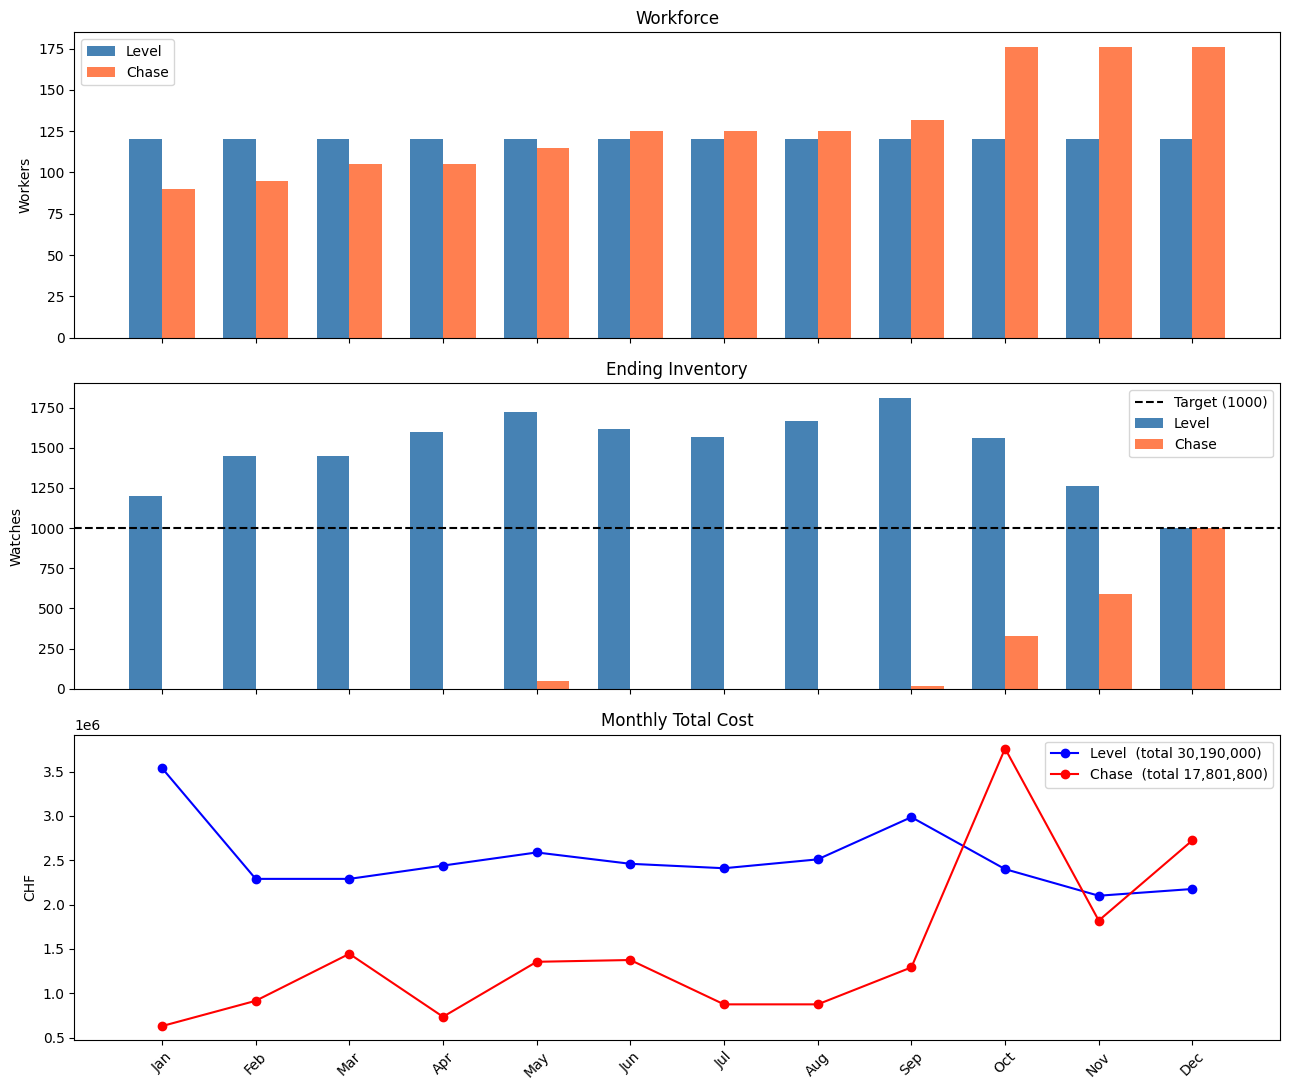

In [9]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model2(strategy="level")
df_chase, s_chase = solve_model2(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 3

In [10]:
# ── Model 3: MILP with subcontracting (chase / level) ────────────────────────

def solve_model3(strategy="level", verbose=False):
    """
    Model 3 – subcontracting allowed in Jun, Jul, Oct, Dec (no overtime).

    Decision variables:
        W[t]  : workforce at end of month t
        H[t]  : workers hired at start of month t
        P[t]  : Production of month t
        F[t]  : workers fired at start of month t
        I[t]  : ending inventory in month t
        S[t]  : subcontracted watches in month t (only in subcontracting months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model3_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H = [LpVariable(f"H_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    F = [LpVariable(f"F_{t}", lowBound=0, cat=LpInteger) for t in range(T)]
    I = [LpVariable(f"I_{t}", lowBound=0)                for t in range(T)]
    S = [LpVariable(f"S_{t}", lowBound=0)                for t in range(T)]
    P = [LpVariable(f"P_{t}", lowBound=0)                for t in range(T)]

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker    * W[t] for t in range(T))
      + lpSum(hiring_cost        * H[t] for t in range(T))
      + lpSum(layoff_cost        * F[t] for t in range(T))
      + lpSum(holding_cost       * I[t] for t in range(T))
      + lpSum(subcontracting_cost * S[t] for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W   = W0 if t == 0 else W[t-1]
        prev_I   = I0 if t == 0 else I[t-1]
        month_num = t + 1   # subcontracting_months is 1-indexed

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t], f"workforce_{t}"

        # Inventory balance (regular production + subcontracting)
        prob += (I[t] == prev_I + P[t] + S[t] - demand_list[t],
                 f"inventory_{t}")
        if strategy == "level":
            # Force full capacity utilisation — production must equal max capacity
            prob += P[t] == prod_per_worker * W[t],      f"prod_cap_{t}"
        else:
            # Cap production at max capacity — solver can choose to produce less
            prob += P[t] <= prod_per_worker * W[t],      f"prod_cap_{t}"

        # Subcontracting cap
        prob += S[t] <= subcontracting_limit, f"sc_cap_{t}"

        # Subcontracting only allowed in designated months
        if month_num not in subcontracting_months:
            prob += S[t] == 0, f"sc_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers      = [int(round(value(W[t]))) for t in range(T)]
    hired        = [int(round(value(H[t]))) for t in range(T)]
    fired        = [int(round(value(F[t]))) for t in range(T)]
    subcontracted = [value(S[t])            for t in range(T)]
    inventory    = [value(I[t])             for t in range(T)]

    wage_c  = [wage_per_worker     * workers[t]       for t in range(T)]
    hire_c  = [hiring_cost         * hired[t]         for t in range(T)]
    layoff_c = [layoff_cost        * fired[t]         for t in range(T)]
    inv_c   = [holding_cost        * inventory[t]     for t in range(T)]
    sc_c    = [subcontracting_cost * subcontracted[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [value(P[t]) for t in range(T)],
        "Subcontracted":  [int(round(s)) for s in subcontracted],
        "Total Prod.":    [value(P[t]) + int(round(subcontracted[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "SC Cost":        sc_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+sc_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":           strategy,
        "Status":             prob.status,
        "Total Wage":         sum(wage_c),
        "Total Hiring":       sum(hire_c),
        "Total Layoff":       sum(layoff_c),
        "Total Subcontracting": sum(sc_c),
        "Total Inventory":    sum(inv_c),
        "Grand Total":        sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(sc_c)+sum(inv_c),
    }

    return df, summary

In [11]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model3(strategy=strat)
    print(f"\n{'═'*60}")
    print(f"  MODEL 3 – {strat.upper()} STRATEGY")
    print(f"{'═'*60}")
    display(df)
    print(f"\n── Cost Summary (CHF) ──")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")


════════════════════════════════════════════════════════════
  MODEL 3 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,124,34,0,"1,240",0,"1,240",900,1240,868000,1700000,0,0,"1,240,000","3,808,000"
1,Feb,124,0,0,"1,240",0,"1,240",950,1530,868000,0,0,0,"1,530,000","2,398,000"
2,Mar,124,0,0,"1,240",0,"1,240",1200,1570,868000,0,0,0,"1,570,000","2,438,000"
3,Apr,124,0,0,"1,240",0,"1,240",1050,1760,868000,0,0,0,"1,760,000","2,628,000"
4,May,124,0,0,"1,240",0,"1,240",1100,1900,868000,0,0,0,"1,900,000","2,768,000"
5,Jun,124,0,0,"1,240",0,"1,240",1300,1840,868000,0,0,0,"1,840,000","2,708,000"
6,Jul,124,0,0,"1,240",0,"1,240",1250,1830,868000,0,0,0,"1,830,000","2,698,000"
7,Aug,124,0,0,"1,240",0,"1,240",1100,1970,868000,0,0,0,"1,970,000","2,838,000"
8,Sep,124,0,0,"1,240",0,"1,240",1300,1910,868000,0,0,0,"1,910,000","2,778,000"
9,Oct,124,0,0,"1,240",0,"1,240",1450,1700,868000,0,0,0,"1,700,000","2,568,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,416,000
  Total Hiring        :       1,700,000
  Total Layoff        :               0
  Total Subcontracting:         300,000
  Total Inventory     :      19,690,000
  Grand Total         :      32,106,000

════════════════════════════════════════════════════════════
  MODEL 3 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,0,0,900,0,630000,0,0,0,0,"630,000"
1,Feb,100,10,0,"1,000",0,"1,000",950,50,700000,500000,0,0,"50,000","1,250,000"
2,Mar,115,15,0,"1,150",0,"1,150",1200,0,805000,750000,0,0,0,"1,555,000"
3,Apr,115,0,0,"1,050",0,"1,050",1050,0,805000,0,0,0,0,"805,000"
4,May,115,0,0,"1,150",0,"1,150",1100,50,805000,0,0,0,"50,000","855,000"
5,Jun,125,10,0,"1,250",0,"1,250",1300,0,875000,500000,0,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",0,"1,250",1250,0,875000,0,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",0,"1,100",1100,0,875000,0,0,0,0,"875,000"
8,Sep,131,6,0,"1,310",0,"1,310",1300,10,917000,300000,0,0,"10,000","1,227,000"
9,Oct,188,57,0,"1,880",0,"1,880",1450,440,1316000,2850000,0,0,"440,000","4,606,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      11,235,000
  Total Hiring        :       4,900,000
  Total Layoff        :               0
  Total Subcontracting:               0
  Total Inventory     :       2,370,000
  Grand Total         :      18,505,000


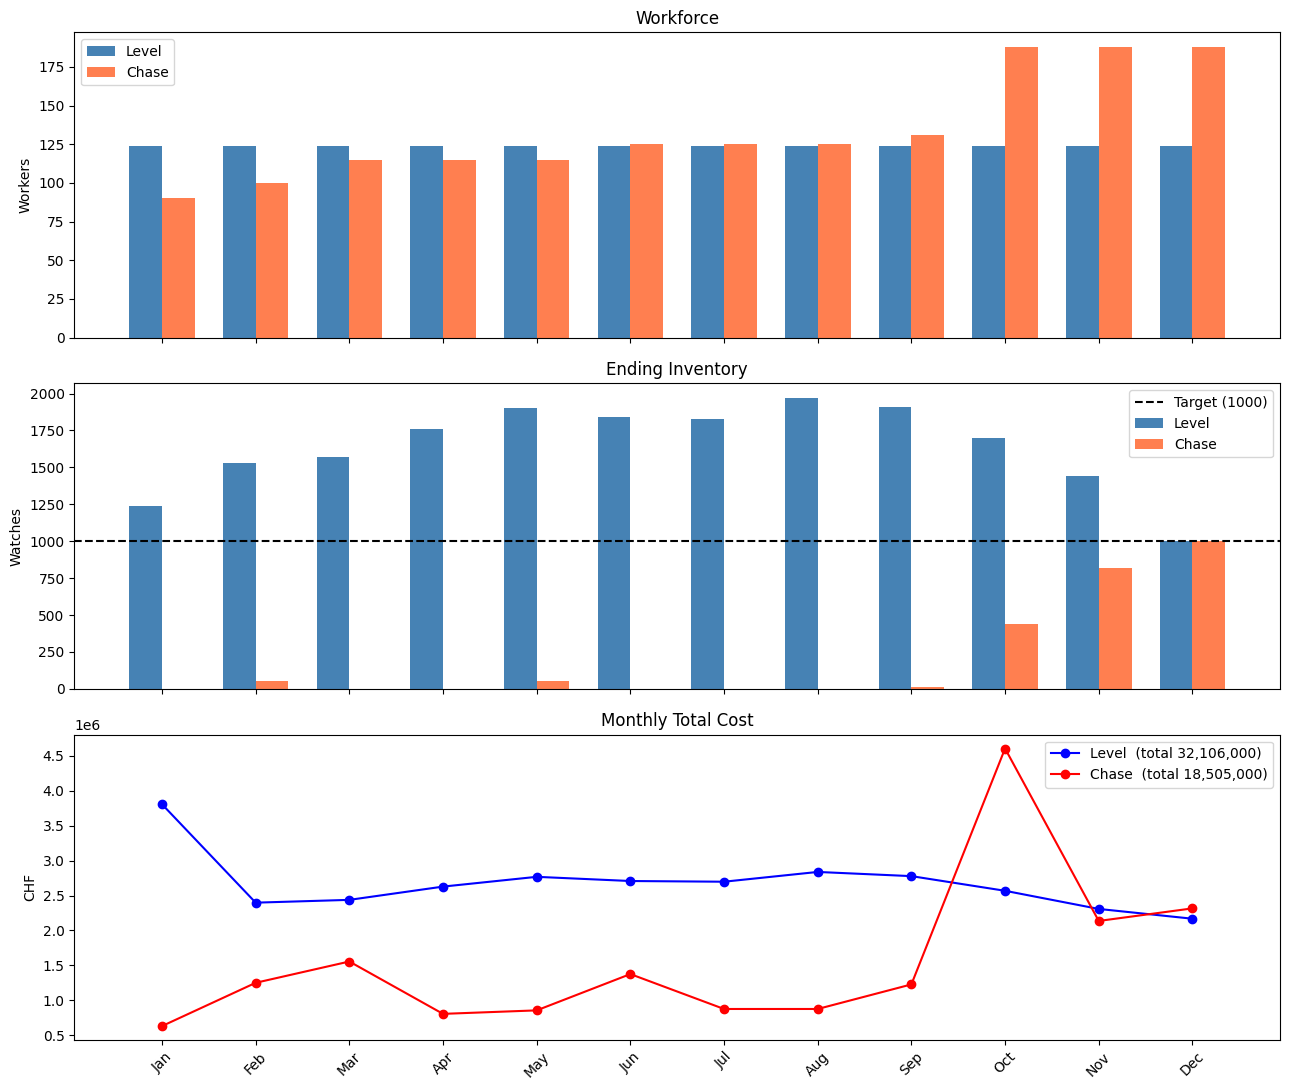

In [12]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model3(strategy="level")
df_chase, s_chase = solve_model3(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

##Model 4


In [13]:
# ── Model 4: MILP with overtime + subcontracting (chase / level) ──────────────

def solve_model4(strategy="level", verbose=False):
    """
    Model 4 – overtime (Mar, May, Sep, Dec) + subcontracting (Jun, Jul, Oct, Dec).

    Decision variables:
        W[t]  : workforce at end of month t
        H[t]  : workers hired at start of month t
        F[t]  : workers fired at start of month t
        P[t]  : Production of month t
        I[t]  : ending inventory in month t
        OT[t] : overtime production in month t (only in overtime months)
        S[t]  : subcontracted watches in month t (only in subcontracting months)

    strategy : "level" → workforce fixed to a single constant W*
               "chase" → workforce free to change each month
    """
    assert strategy in ("level", "chase"), "strategy must be 'level' or 'chase'"

    prob = LpProblem(f"Aurelius_Model4_{strategy}", LpMinimize)

    # ── Decision variables ────────────────────────────────────────────────────
    if strategy == "level":
        W_star = LpVariable("W_star", lowBound=0, cat=LpInteger)
        W = [W_star] * T
    else:
        W = [LpVariable(f"W_{t}", lowBound=0, cat=LpInteger) for t in range(T)]

    H  = [LpVariable(f"H_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    F  = [LpVariable(f"F_{t}",  lowBound=0, cat=LpInteger) for t in range(T)]
    I  = [LpVariable(f"I_{t}",  lowBound=0)                for t in range(T)]
    OT = [LpVariable(f"OT_{t}", lowBound=0)                for t in range(T)]
    S  = [LpVariable(f"S_{t}",  lowBound=0)                for t in range(T)]
    P  = [LpVariable(f"P_{t}", lowBound=0)                 for t in range(T)]

    # Overtime cost per watch produced
    ot_cost_per_watch = (wage_per_worker * overtime_cost_multiplier) / prod_per_worker

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        lpSum(wage_per_worker     * W[t]  for t in range(T))
      + lpSum(hiring_cost         * H[t]  for t in range(T))
      + lpSum(layoff_cost         * F[t]  for t in range(T))
      + lpSum(holding_cost        * I[t]  for t in range(T))
      + lpSum(ot_cost_per_watch   * OT[t] for t in range(T))
      + lpSum(subcontracting_cost * S[t]  for t in range(T))
    ), "Total_Cost"

    # ── Constraints ───────────────────────────────────────────────────────────
    for t in range(T):
        prev_W    = W0 if t == 0 else W[t-1]
        prev_I    = I0 if t == 0 else I[t-1]
        month_num = t + 1

        # Workforce balance
        prob += W[t] == prev_W + H[t] - F[t], f"workforce_{t}"

        # Inventory balance (regular + overtime + subcontracting)
        prob += (I[t] == prev_I + P[t] + OT[t] + S[t] - demand_list[t],
                 f"inventory_{t}")

        # Overtime cap: up to overtime_allowance × regular capacity
        prob += OT[t] <= overtime_allowance * prod_per_worker * W[t], f"ot_cap_{t}"

        # Subcontracting cap
        prob += S[t] <= subcontracting_limit, f"sc_cap_{t}"

        if strategy == "level":
            # Force full capacity utilisation — production must equal max capacity
            prob += P[t] == prod_per_worker * W[t],      f"prod_cap_{t}"
        else:
            # Cap production at max capacity — solver can choose to produce less
            prob += P[t] <= prod_per_worker * W[t],      f"prod_cap_{t}"

        # Overtime only in designated months
        if month_num not in overtime_months:
            prob += OT[t] == 0, f"ot_forbidden_{t}"

        # Subcontracting only in designated months
        if month_num not in subcontracting_months:
            prob += S[t] == 0, f"sc_forbidden_{t}"

    # Final inventory target
    prob += I[T-1] >= I_T, "final_inventory"

    # ── Solve ─────────────────────────────────────────────────────────────────
    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract results ───────────────────────────────────────────────────────
    workers       = [int(round(value(W[t])))  for t in range(T)]
    hired         = [int(round(value(H[t])))  for t in range(T)]
    fired         = [int(round(value(F[t])))  for t in range(T)]
    overtime      = [value(OT[t])             for t in range(T)]
    subcontracted = [value(S[t])              for t in range(T)]
    inventory     = [value(I[t])              for t in range(T)]

    wage_c    = [wage_per_worker     * workers[t]       for t in range(T)]
    hire_c    = [hiring_cost         * hired[t]         for t in range(T)]
    layoff_c  = [layoff_cost         * fired[t]         for t in range(T)]
    inv_c     = [holding_cost        * inventory[t]     for t in range(T)]
    ot_c      = [ot_cost_per_watch   * overtime[t]      for t in range(T)]
    sc_c      = [subcontracting_cost * subcontracted[t] for t in range(T)]

    df = pd.DataFrame({
        "Month":          MONTH_NAMES,
        "Workers":        workers,
        "Hired":          hired,
        "Laid Off":       fired,
        "Reg. Prod.":     [value(P[t]) for t in range(T)],
        "OT Prod.":       [int(round(o)) for o in overtime],
        "Subcontracted":  [int(round(s)) for s in subcontracted],
        "Total Prod.":    [value(P[t]) + int(round(overtime[t])) + int(round(subcontracted[t])) for t in range(T)],
        "Demand":         demand_list,
        "End Inventory":  [int(round(i)) for i in inventory],
        "Wage Cost":      wage_c,
        "Hiring Cost":    hire_c,
        "Layoff Cost":    layoff_c,
        "OT Cost":        ot_c,
        "SC Cost":        sc_c,
        "Inventory Cost": inv_c,
        "Total Cost":     [wage_c[t]+hire_c[t]+layoff_c[t]+ot_c[t]+sc_c[t]+inv_c[t] for t in range(T)],
    })

    summary = {
        "Strategy":             strategy,
        "Status":               prob.status,
        "Total Wage":           sum(wage_c),
        "Total Hiring":         sum(hire_c),
        "Total Layoff":         sum(layoff_c),
        "Total OT":             sum(ot_c),
        "Total Subcontracting": sum(sc_c),
        "Total Inventory":      sum(inv_c),
        "Grand Total":          sum(wage_c)+sum(hire_c)+sum(layoff_c)+sum(ot_c)+sum(sc_c)+sum(inv_c),
    }

    return df, summary

In [14]:
# ── Run both strategies ───────────────────────────────────────────────────────

pd.set_option("display.float_format", "{:,.0f}".format)

for strat in ("level", "chase"):
    df, s = solve_model4(strategy=strat)
    print(f"\n{'\u2550'*60}")
    print(f"  MODEL 4 \u2013 {strat.upper()} STRATEGY")
    print(f"{'\u2550'*60}")
    display(df)
    print(f"\n\u2500\u2500 Cost Summary (CHF) \u2500\u2500")
    for k, v in s.items():
        if k in ("Strategy", "Status"):
            print(f"  {k:<20}: {v}")
        else:
            print(f"  {k:<20}: {v:>15,.0f}")



════════════════════════════════════════════════════════════
  MODEL 4 – LEVEL STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,120,30,0,"1,200",0,0,"1,200",900,1200,840000,1500000,0,0,0,"1,200,000","3,540,000"
1,Feb,120,0,0,"1,200",0,0,"1,200",950,1450,840000,0,0,0,0,"1,450,000","2,290,000"
2,Mar,120,0,0,"1,200",0,0,"1,200",1200,1450,840000,0,0,0,0,"1,450,000","2,290,000"
3,Apr,120,0,0,"1,200",0,0,"1,200",1050,1600,840000,0,0,0,0,"1,600,000","2,440,000"
4,May,120,0,0,"1,200",20,0,"1,220",1100,1720,840000,0,0,"28,000",0,"1,720,000","2,588,000"
5,Jun,120,0,0,"1,200",0,0,"1,200",1300,1620,840000,0,0,0,0,"1,620,000","2,460,000"
6,Jul,120,0,0,"1,200",0,0,"1,200",1250,1570,840000,0,0,0,0,"1,570,000","2,410,000"
7,Aug,120,0,0,"1,200",0,0,"1,200",1100,1670,840000,0,0,0,0,"1,670,000","2,510,000"
8,Sep,120,0,0,"1,200",240,0,"1,440",1300,1810,840000,0,0,"336,000",0,"1,810,000","2,986,000"
9,Oct,120,0,0,"1,200",0,0,"1,200",1450,1560,840000,0,0,0,0,"1,560,000","2,400,000"



── Cost Summary (CHF) ──
  Strategy            : level
  Status              : 1
  Total Wage          :      10,080,000
  Total Hiring        :       1,500,000
  Total Layoff        :               0
  Total OT            :         700,000
  Total Subcontracting:               0
  Total Inventory     :      17,910,000
  Grand Total         :      30,190,000

════════════════════════════════════════════════════════════
  MODEL 4 – CHASE STRATEGY
════════════════════════════════════════════════════════════


,Month,Workers,Hired,Laid Off,Reg. Prod.,OT Prod.,Subcontracted,Total Prod.,Demand,End Inventory,Wage Cost,Hiring Cost,Layoff Cost,OT Cost,SC Cost,Inventory Cost,Total Cost
0,Jan,90,0,0,0,0,0,0,900,0,630000,0,0,0,0,0,"630,000"
1,Feb,95,5,0,950,0,0,950,950,0,665000,250000,0,0,0,0,"915,000"
2,Mar,105,10,0,"1,050",150,0,"1,200",1200,0,735000,500000,0,"210,000",0,0,"1,445,000"
3,Apr,105,0,0,"1,050",0,0,"1,050",1050,0,735000,0,0,0,0,0,"735,000"
4,May,115,10,0,"1,150",0,0,"1,150",1100,50,805000,500000,0,0,0,"50,000","1,355,000"
5,Jun,125,10,0,"1,250",0,0,"1,250",1300,0,875000,500000,0,0,0,0,"1,375,000"
6,Jul,125,0,0,"1,250",0,0,"1,250",1250,0,875000,0,0,0,0,0,"875,000"
7,Aug,125,0,0,"1,100",0,0,"1,100",1100,0,875000,0,0,0,0,0,"875,000"
8,Sep,132,7,0,"1,318",0,0,"1,318",1300,18,924000,350000,0,0,0,"18,000","1,292,000"
9,Oct,176,44,0,"1,760",0,0,"1,760",1450,328,1232000,2200000,0,0,0,"328,000","3,760,000"



── Cost Summary (CHF) ──
  Strategy            : chase
  Status              : 1
  Total Wage          :      10,815,000
  Total Hiring        :       4,300,000
  Total Layoff        :               0
  Total OT            :         702,800
  Total Subcontracting:               0
  Total Inventory     :       1,984,000
  Grand Total         :      17,801,800


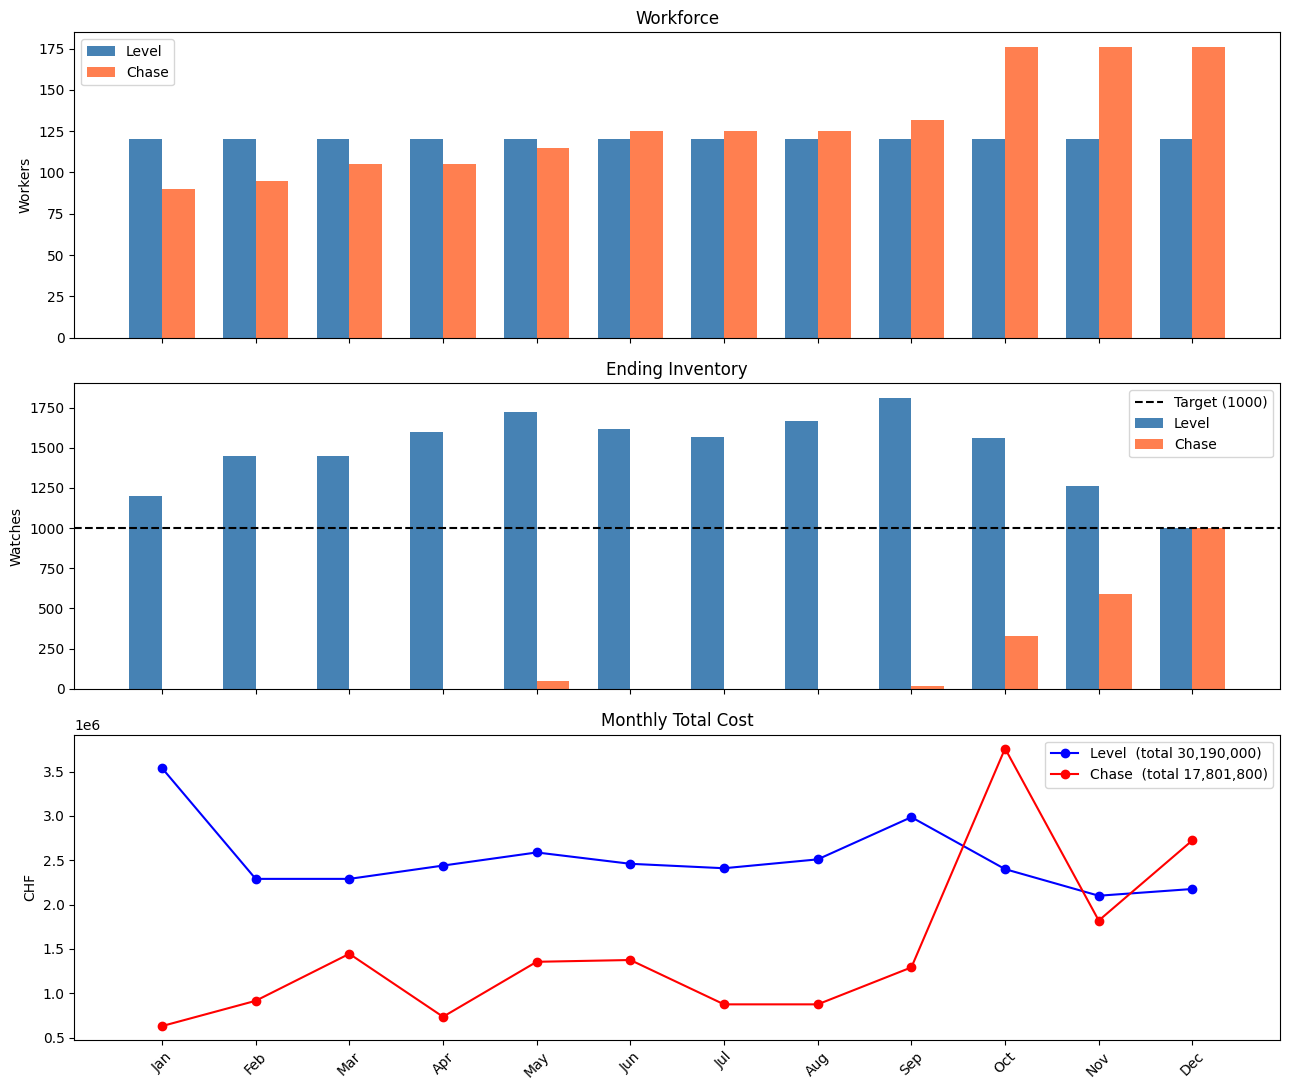

In [15]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────

df_level, s_level = solve_model4(strategy="level")
df_chase, s_chase = solve_model4(strategy="chase")

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)
x  = range(T)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

# Workers
axes[0].bar(x1, df_level["Workers"], width=w, color="steelblue", label="Level")
axes[0].bar(x2, df_chase["Workers"], width=w, color="coral",     label="Chase")
axes[0].set_ylabel("Workers"); axes[0].set_title("Workforce"); axes[0].legend()

# Inventory
axes[1].bar(x1, df_level["End Inventory"], width=w, color="steelblue", label="Level")
axes[1].bar(x2, df_chase["End Inventory"], width=w, color="coral",     label="Chase")
axes[1].axhline(I_T, color="black", linestyle="--", label=f"Target ({I_T})")
axes[1].set_ylabel("Watches"); axes[1].set_title("Ending Inventory"); axes[1].legend()

# Monthly total cost
axes[2].plot(x, df_level["Total Cost"], "bo-", label=f"Level  (total {s_level['Grand Total']:,.0f})")
axes[2].plot(x, df_chase["Total Cost"], "ro-", label=f"Chase  (total {s_chase['Grand Total']:,.0f})")
axes[2].set_ylabel("CHF"); axes[2].set_title("Monthly Total Cost")
axes[2].set_xticks(x); axes[2].set_xticklabels(MONTH_NAMES, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

## Graphs + Cross-Model Comparison


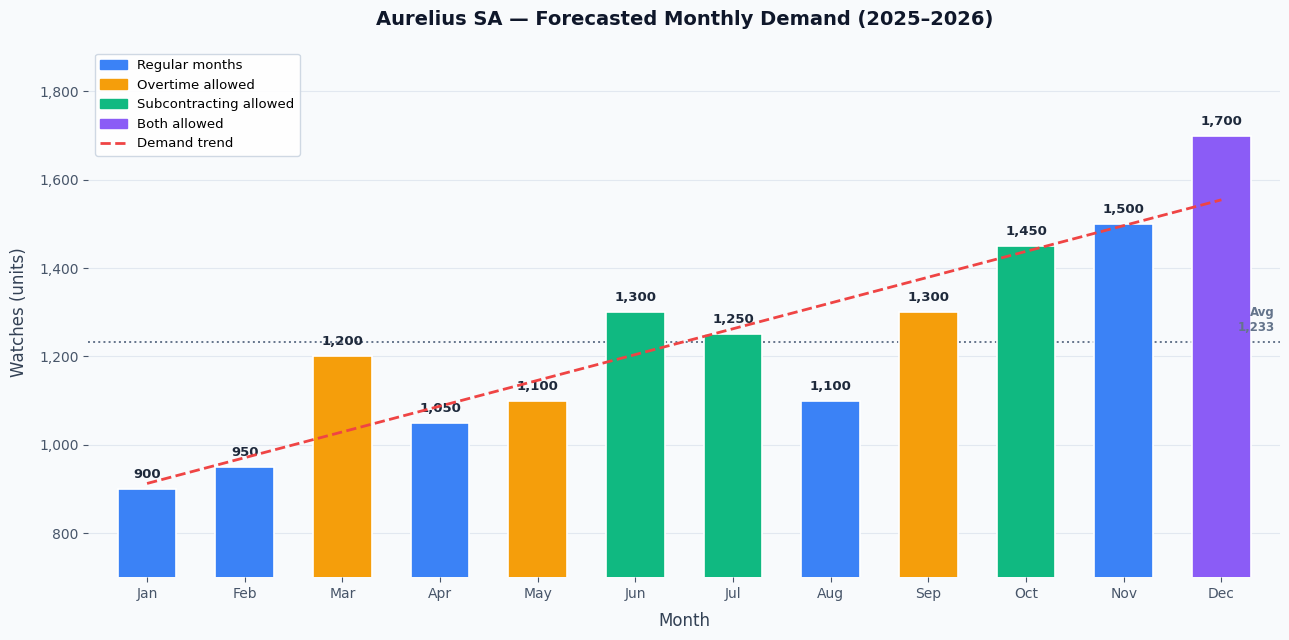

In [16]:
# ── Forecasted Monthly Demand Chart ──────────────────────────────────────────

# Overtime and subcontracting months (1-indexed)
overtime_months_set      = {3, 5, 9, 12}   # Mar, May, Sep, Dec
subcontracting_months_set = {6, 7, 10, 12} # Jun, Jul, Oct, Dec

# Color each bar
colors = []
for i in range(1, 13):
    if i in overtime_months_set and i in subcontracting_months_set:
        colors.append("#8B5CF6")   # purple = both
    elif i in overtime_months_set:
        colors.append("#F59E0B")   # amber = overtime
    elif i in subcontracting_months_set:
        colors.append("#10B981")   # green = subcontracting
    else:
        colors.append("#3B82F6")   # blue = regular

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# Bars
bars = ax.bar(MONTH_NAMES, demand_list, color=colors, width=0.6,
              edgecolor="white", linewidth=1.2, zorder=3)

# Trend line
x_num = np.arange(len(MONTH_NAMES))
z = np.polyfit(x_num, demand_list, 1)
p = np.poly1d(z)
ax.plot(MONTH_NAMES, p(x_num), color="#EF4444", linewidth=2,
        linestyle="--", zorder=4, label="Trend")

# Value labels on bars
for bar, val in zip(bars, demand_list):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 18,
            f"{val:,}", ha="center", va="bottom",
            fontsize=9.5, fontweight="bold", color="#1E293B")

# Reference line: average demand
avg = sum(demand_list) / len(demand_list)
ax.axhline(avg, color="#64748B", linewidth=1.4, linestyle=":", zorder=2)
ax.text(11.55, avg + 18, f"Avg\n{avg:,.0f}",
        ha="right", va="bottom", fontsize=8.5,
        color="#64748B", fontweight="bold")

# Axes styling
ax.set_ylim(700, 1900)
ax.set_xlim(-0.6, 11.6)
ax.set_xlabel("Month", fontsize=12, color="#334155", labelpad=8)
ax.set_ylabel("Watches (units)", fontsize=12, color="#334155", labelpad=8)
ax.set_title("Aurelius SA — Forecasted Monthly Demand (2025–2026)",
             fontsize=14, fontweight="bold", color="#0F172A", pad=16)

ax.tick_params(colors="#475569", labelsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Legend
legend_items = [
    mpatches.Patch(color="#3B82F6", label="Regular months"),
    mpatches.Patch(color="#F59E0B", label="Overtime allowed"),
    mpatches.Patch(color="#10B981", label="Subcontracting allowed"),
    mpatches.Patch(color="#8B5CF6", label="Both allowed"),
    plt.Line2D([0], [0], color="#EF4444", linewidth=2,
               linestyle="--", label="Demand trend"),
]
ax.legend(handles=legend_items, loc="upper left",
          frameon=True, framealpha=0.9, fontsize=9.5,
          edgecolor="#CBD5E1")

plt.tight_layout()
plt.show()


=== Grand Total Cost Comparison (CHF) ===


,Model 1 (Base),Model 2 (+OT),Model 3 (+SC),Model 4 (OT+SC)
Strategy,,,,
level,"32,700,000","30,190,000","32,106,000","30,190,000"
chase,"18,505,000","17,801,800","18,505,000","17,801,800"


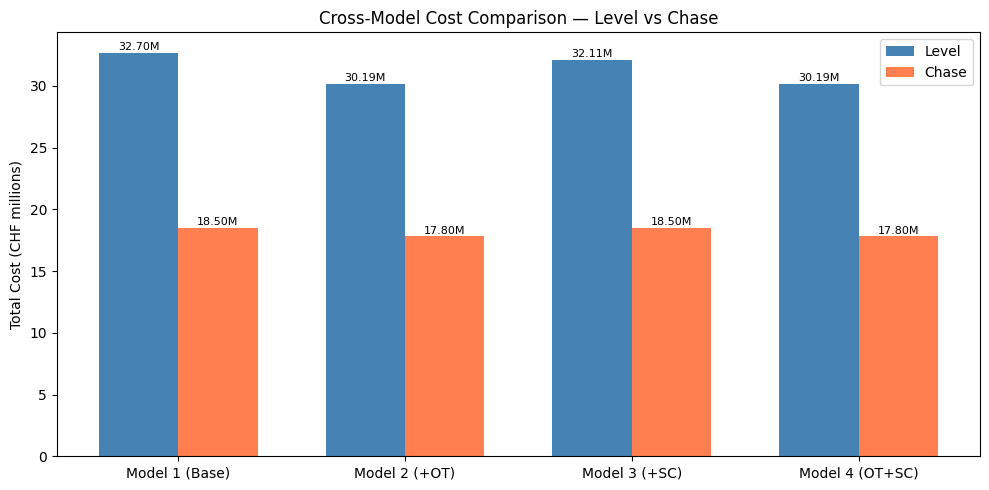

In [17]:
# ── Collect results from all 4 models (both strategies) and compare ──────────

model_results = {}
for strat in ("level", "chase"):
    _, s1 = solve_model1(strategy=strat)
    _, s2 = solve_model2(strategy=strat)
    _, s3 = solve_model3(strategy=strat)
    _, s4 = solve_model4(strategy=strat)
    model_results[strat] = {
        "Model 1 (Base)":        s1["Grand Total"],
        "Model 2 (+OT)":         s2["Grand Total"],
        "Model 3 (+SC)":         s3["Grand Total"],
        "Model 4 (OT+SC)":       s4["Grand Total"],
    }

df_comp = pd.DataFrame(model_results).T
df_comp.index.name = "Strategy"
print("\n=== Grand Total Cost Comparison (CHF) ===")
display(df_comp.style.format("{:,.0f}"))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.35
labels = list(model_results["level"].keys())
level_vals = list(model_results["level"].values())
chase_vals = list(model_results["chase"].values())

bars1 = ax.bar(x - w/2, [v/1e6 for v in level_vals], w, color="steelblue", label="Level")
bars2 = ax.bar(x + w/2, [v/1e6 for v in chase_vals],  w, color="coral",     label="Chase")

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{bar.get_height():.2f}M", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Total Cost (CHF millions)")
ax.set_title("Cross-Model Cost Comparison — Level vs Chase")
ax.legend()
plt.tight_layout()
plt.show()


## Inventory Management


In [18]:
# ── Inventory Management Parameters ──────────────────────────────────────────
from scipy.stats import norm
from matplotlib.patches import Patch

SERVICE_LEVEL = 0.98
Z             = norm.ppf(SERVICE_LEVEL)
WORKING_DAYS  = 365

print(f"Service level : {SERVICE_LEVEL:.0%}")
print(f"z-score (z_{SERVICE_LEVEL:.0%}): {Z:.4f}")


# ── EOQ & Reorder Point Calculations ─────────────────────────────────────────

rows = []
for comp, p in components.items():
    mu_annual  = demand_stats[comp]["mean_daily"] * WORKING_DAYS
    sigma_d    = demand_stats[comp]["std_daily"]
    L          = p["lead_time_days"]
    h          = p["holding_cost_per_unit_month"] * 12
    K          = p["ordering_cost"]

    eoq        = np.sqrt(2 * K * mu_annual / h)
    sigma_L    = sigma_d * np.sqrt(L)
    mu_L       = demand_stats[comp]["mean_daily"] * L
    ss         = Z * sigma_L
    R          = mu_L + ss
    cycle_time = eoq / demand_stats[comp]["mean_daily"]
    shelf_ok   = "✓" if cycle_time <= p["shelf_life_days"] else "✗"
    n_orders   = mu_annual / eoq
    ann_cost   = (K * n_orders
                  + h * (eoq / 2)
                  + p["holding_cost_per_unit_month"] * ss)

    rows.append({
        "Component":         comp,
        "μ_daily":           round(demand_stats[comp]["mean_daily"], 3),
        "σ_daily":           round(sigma_d, 3),
        "Lead Time (days)":  L,
        "EOQ":               round(eoq, 1),
        "Safety Stock":      round(ss, 2),
        "Reorder Point (R)": round(R, 1),
        "Cycle Time (days)": round(cycle_time, 1),
        "Shelf Life (days)": p["shelf_life_days"],
        "Shelf Check":       shelf_ok,
        "Ann. Cost (CHF)":   round(ann_cost, 0),
    })

df_inv = pd.DataFrame(rows)
display(df_inv)


Service level : 98%
z-score (z_98%): 2.0537


,Component,μ_daily,σ_daily,Lead Time (days),EOQ,Safety Stock,Reorder Point (R),Cycle Time (days),Shelf Life (days),Shelf Check,Ann. Cost (CHF)
0,3235 Movement,14,4,60,81,57,912,6,365,✓,"1,229,507"
1,Oystersteel Case,15,4,45,127,59,742,8,505,✓,"633,747"
2,Sapphire Crystal,14,4,30,132,40,467,9,365,✓,"323,651"
3,Jubilee Bracelet,8,1,35,88,12,293,11,1460,✓,"235,192"
4,Lubricant Oil,151,41,14,428,316,"2,427",3,730,✓,"272,760"
5,Diamond Marker,48,5,21,139,48,"1,052",3,1825,✓,"1,546,939"
6,Gold Crown,8,3,40,83,39,360,10,730,✓,"364,108"


,Component,ABC,Cumulative %,Ann. Cost (CHF),Policy
0,Diamond Marker,A,34,"1,546,939","(Q,R) Continuous Review"
1,3235 Movement,A,60,"1,229,507","(Q,R) Continuous Review"
2,Oystersteel Case,B,74,"633,747","(Q,R) or (P,T)"
3,Gold Crown,B,82,"364,108","(Q,R) or (P,T)"
4,Sapphire Crystal,B,89,"323,651","(Q,R) or (P,T)"
5,Lubricant Oil,C,95,"272,760","(P,T) Periodic Review"
6,Jubilee Bracelet,C,100,"235,192","(P,T) Periodic Review"


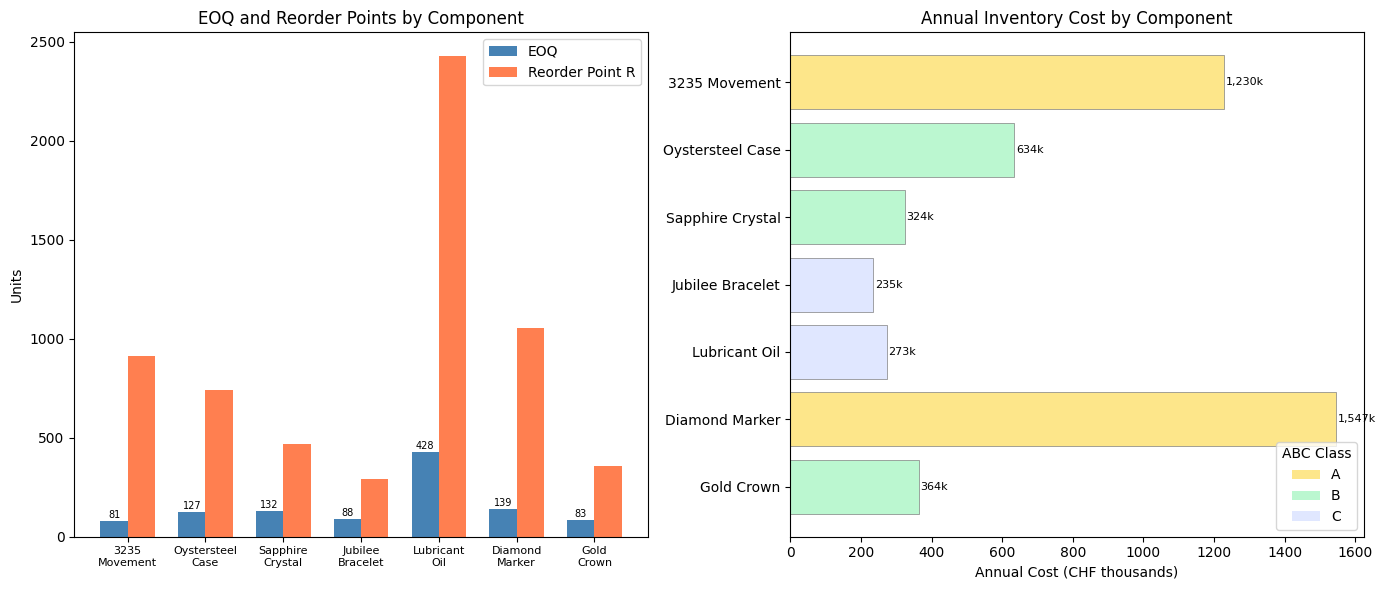

In [19]:


# ── ABC Classification & Policy Recommendation ───────────────────────────────

total_cost     = df_inv["Ann. Cost (CHF)"].sum()
df_inv_sorted  = df_inv.sort_values("Ann. Cost (CHF)", ascending=False).copy()
df_inv_sorted["Cumulative %"] = df_inv_sorted["Ann. Cost (CHF)"].cumsum() / total_cost * 100

def abc_class(cum_pct):
    if cum_pct <= 70:  return "A"
    elif cum_pct <= 90: return "B"
    else:               return "C"

def recommend_policy(row):
    if row["ABC"] == "A":   return "(Q,R) Continuous Review"
    elif row["ABC"] == "B": return "(Q,R) or (P,T)"
    else:                   return "(P,T) Periodic Review"

df_inv_sorted["ABC"]    = df_inv_sorted["Cumulative %"].apply(abc_class)
df_inv_sorted["Policy"] = df_inv_sorted.apply(recommend_policy, axis=1)

df_policy = df_inv_sorted[["Component","ABC","Cumulative %","Ann. Cost (CHF)","Policy"]].reset_index(drop=True)
df_policy["Cumulative %"] = df_policy["Cumulative %"].round(1)
display(df_policy)


# ── Visualisation ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

comp_labels = [c.replace(" ", "\n") for c in df_inv["Component"]]
x = np.arange(len(comp_labels))
w = 0.35

ax = axes[0]
b1 = ax.bar(x - w/2, df_inv["EOQ"],               width=w, color="steelblue", label="EOQ")
b2 = ax.bar(x + w/2, df_inv["Reorder Point (R)"], width=w, color="coral",     label="Reorder Point R")
ax.set_xticks(x); ax.set_xticklabels(comp_labels, fontsize=8)
ax.set_ylabel("Units"); ax.set_title("EOQ and Reorder Points by Component")
ax.legend()
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=7)

ax2 = axes[1]
colors_abc = {"A": "#fde68a", "B": "#bbf7d0", "C": "#e0e7ff"}
abc_map    = dict(zip(df_policy["Component"], df_policy["ABC"]))
bar_colors = [colors_abc[abc_map[c]] for c in df_inv["Component"]]
bars = ax2.barh(df_inv["Component"], df_inv["Ann. Cost (CHF)"] / 1e3,
                color=bar_colors, edgecolor="grey", linewidth=0.5)
ax2.set_xlabel("Annual Cost (CHF thousands)")
ax2.set_title("Annual Inventory Cost by Component")
ax2.invert_yaxis()
for bar, val in zip(bars, df_inv["Ann. Cost (CHF)"]):
    ax2.text(bar.get_width() + 5, bar.get_y()+bar.get_height()/2,
             f"{val/1e3:,.0f}k", va="center", fontsize=8)

legend_els = [Patch(facecolor="#fde68a", label="A"),
              Patch(facecolor="#bbf7d0", label="B"),
              Patch(facecolor="#e0e7ff", label="C")]
ax2.legend(handles=legend_els, title="ABC Class", loc="lower right")

plt.tight_layout()
plt.show()

#**PART 2**

##LS-U


  MODEL LS-U — UNCAPACITATED LOT-SIZING

── Heritage ──


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,150,150,0,1,"1,200,000",0,"20,000","1,220,000"
1,Feb,140,140,0,1,"1,120,000",0,"20,000","1,140,000"
2,Mar,200,200,0,1,"1,600,000",0,"20,000","1,620,000"
3,Apr,220,220,0,1,"1,760,000",0,"20,000","1,780,000"
4,May,250,250,0,1,"2,000,000",0,"20,000","2,020,000"
5,Jun,300,300,0,1,"2,400,000",0,"20,000","2,420,000"
6,Jul,270,270,0,1,"2,160,000",0,"20,000","2,180,000"
7,Aug,250,250,0,1,"2,000,000",0,"20,000","2,020,000"
8,Sep,320,320,0,1,"2,560,000",0,"20,000","2,580,000"
9,Oct,400,400,0,1,"3,200,000",0,"20,000","3,220,000"



── Chronos ──


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,120,120,0,1,"1,440,000",0,"25,000","1,465,000"
1,Feb,130,130,0,1,"1,560,000",0,"25,000","1,585,000"
2,Mar,150,150,0,1,"1,800,000",0,"25,000","1,825,000"
3,Apr,180,180,0,1,"2,160,000",0,"25,000","2,185,000"
4,May,210,210,0,1,"2,520,000",0,"25,000","2,545,000"
5,Jun,240,240,0,1,"2,880,000",0,"25,000","2,905,000"
6,Jul,230,230,0,1,"2,760,000",0,"25,000","2,785,000"
7,Aug,210,210,0,1,"2,520,000",0,"25,000","2,545,000"
8,Sep,260,260,0,1,"3,120,000",0,"25,000","3,145,000"
9,Oct,300,300,0,1,"3,600,000",0,"25,000","3,625,000"



── Cost Summary (CHF) ──
  Status                : 1
  Total Prod Cost       :      59,360,000
  Total Hold Cost       :               0
  Total Setup Cost      :         540,000
  Grand Total           :      59,900,000


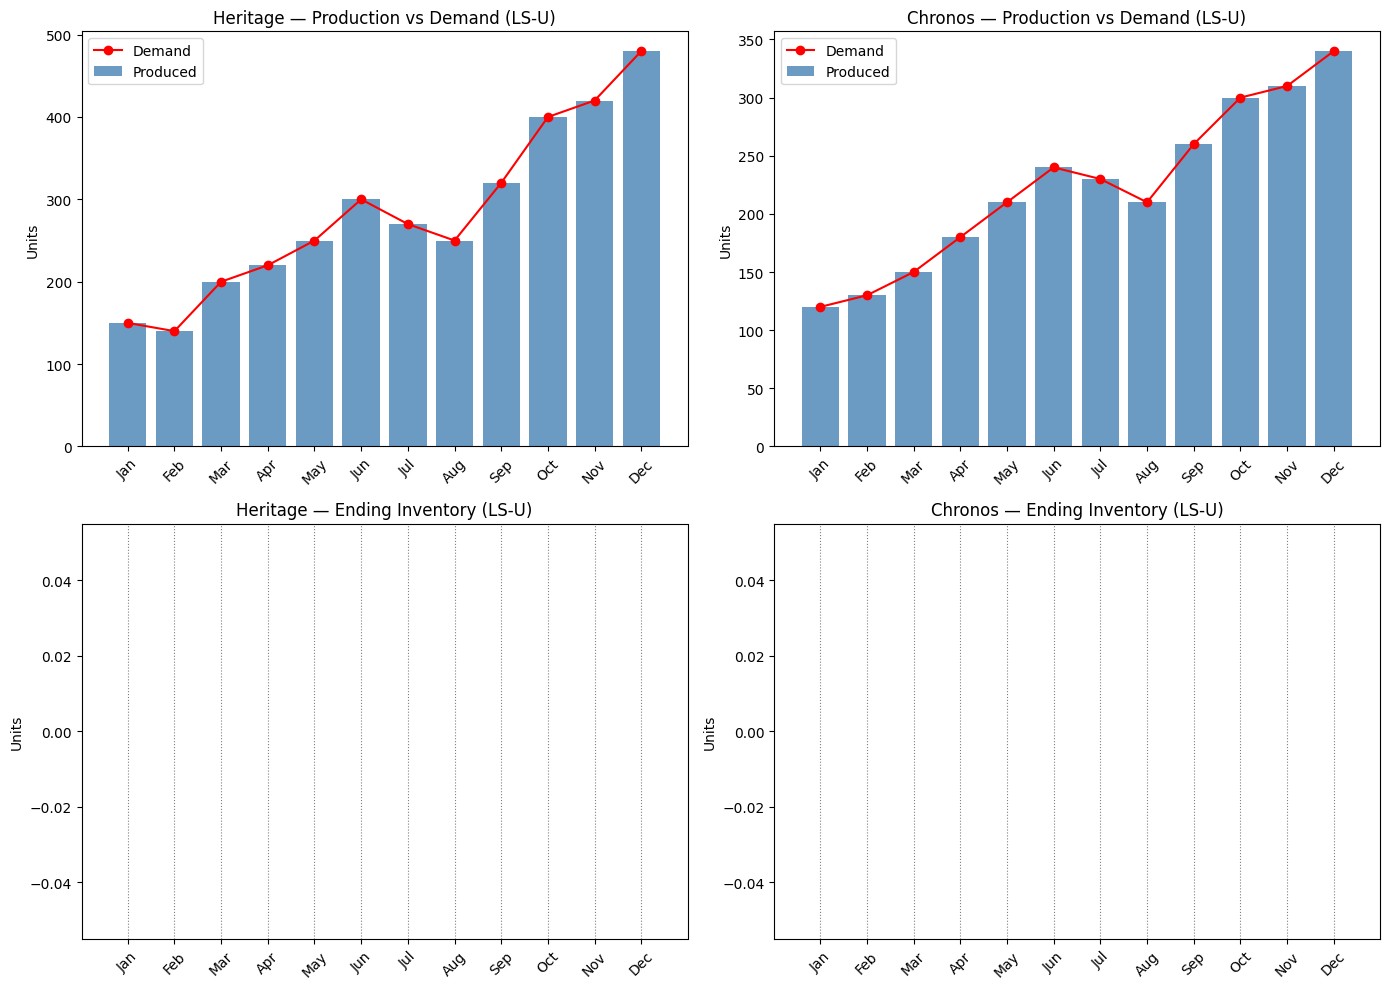

In [20]:
# ── Model LS-U: Uncapacitated Lot-Sizing (Heritage & Chronos) ────────────────
#
# Decision variables:
#   X[p,t] : production quantity of product p in month t  (continuous, >= 0)
#   I[p,t] : ending inventory of product p in month t     (continuous, >= 0)
#   Y[p,t] : binary setup indicator (1 = produce in month t)  in {0,1}
#
# Objective (minimise):
#   sum_{p,t}  prod_cost[p]    * X[p,t]
# + sum_{p,t}  holding_cost[p] * I[p,t]
# + sum_{p,t}  setup_cost[p]   * Y[p,t]
#
# Constraints:
#   Inventory balance : I[p,t] = I[p,t-1] + X[p,t] - d[p,t]   for all p, t
#   Setup linking     : X[p,t] <= M[p] * Y[p,t]                 for all p, t
#   Non-negativity    : X[p,t], I[p,t] >= 0 ;  Y[p,t] in {0,1}
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pulp import (
    LpProblem, LpMinimize, LpVariable, LpBinary,
    lpSum, value, PULP_CBC_CMD
)

# ── Part 2 shared parameters ──────────────────────────────────────────────────
T2           = 12
MONTH_NAMES2 = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
products2    = ["Heritage", "Chronos"]

demand_p2 = {
    "Heritage": [150,140,200,220,250,300,270,250,320,400,420,480],
    "Chronos":  [120,130,150,180,210,240,230,210,260,300,310,340],
}

prod_cost2    = {"Heritage":  8000, "Chronos": 12000}
holding_cost2 = {"Heritage":   150, "Chronos":   200}
setup_cost2   = {"Heritage": 20000, "Chronos": 25000}

# Big-M: upper bound on production in a single period
BIG_M2 = {p: sum(demand_p2[p]) + 1 for p in products2}


# ── Solver ────────────────────────────────────────────────────────────────────
def solve_lsu(verbose=False):
    """
    Uncapacitated Lot-Sizing (LS-U) for Heritage and Chronos.
    No capacity constraint — optimises production, setup, and holding costs.
    """
    prob = LpProblem("Aurelius_LSU", LpMinimize)

    X = {(p,t): LpVariable(f"X_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    I = {(p,t): LpVariable(f"I_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    Y = {(p,t): LpVariable(f"Y_{p}_{t}", cat=LpBinary)
         for p in products2 for t in range(T2)}

    # Objective
    prob += (
        lpSum(prod_cost2[p]    * X[p,t] for p in products2 for t in range(T2))
      + lpSum(holding_cost2[p] * I[p,t] for p in products2 for t in range(T2))
      + lpSum(setup_cost2[p]   * Y[p,t] for p in products2 for t in range(T2))
    ), "Total_Cost"

    # Constraints
    for p in products2:
        for t in range(T2):
            prev_I = 0 if t == 0 else I[p, t-1]
            prob += I[p,t] == prev_I + X[p,t] - demand_p2[p][t], f"inv_{p}_{t}"
            prob += X[p,t] <= BIG_M2[p] * Y[p,t],                f"setup_{p}_{t}"

    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # Extract results
    rows = []
    for p in products2:
        for t in range(T2):
            xv = value(X[p,t]); iv = value(I[p,t]); yv = value(Y[p,t])
            rows.append({
                "Product":    p,
                "Month":      MONTH_NAMES2[t],
                "Produced":   round(xv, 1),
                "Demand":     demand_p2[p][t],
                "End Inv":    round(iv, 1),
                "Setup":      int(round(yv)),
                "Prod Cost":  prod_cost2[p]    * xv,
                "Hold Cost":  holding_cost2[p] * iv,
                "Setup Cost": setup_cost2[p]   * yv,
            })
    df = pd.DataFrame(rows)
    df["Total Cost"] = df["Prod Cost"] + df["Hold Cost"] + df["Setup Cost"]

    summary = {
        "Status":           prob.status,
        "Total Prod Cost":  sum(prod_cost2[p]    * value(X[p,t]) for p in products2 for t in range(T2)),
        "Total Hold Cost":  sum(holding_cost2[p] * value(I[p,t]) for p in products2 for t in range(T2)),
        "Total Setup Cost": sum(setup_cost2[p]   * value(Y[p,t]) for p in products2 for t in range(T2)),
        "Grand Total":      value(prob.objective),
    }
    return df, summary


# ── Run & display ─────────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:,.0f}".format)

df_lsu, s_lsu = solve_lsu()

print(f"\n{'='*60}")
print(f"  MODEL LS-U — UNCAPACITATED LOT-SIZING")
print(f"{'='*60}")

for p in products2:
    print(f"\n── {p} ──")
    sub = df_lsu[df_lsu["Product"] == p].drop(columns="Product").reset_index(drop=True)
    display(sub)

print(f"\n── Cost Summary (CHF) ──")
for k, v in s_lsu.items():
    if k == "Status":
        print(f"  {'Status':<22}: {v}")
    else:
        print(f"  {k:<22}: {v:>15,.0f}")


# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
x = range(T2)

for idx, p in enumerate(products2):
    sub = df_lsu[df_lsu["Product"] == p].reset_index(drop=True)

    ax = axes[0, idx]
    ax.bar(x, sub["Produced"], color="steelblue", label="Produced", alpha=0.8)
    ax.plot(x, sub["Demand"],  "ro-", label="Demand", linewidth=1.5)
    ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax.set_ylabel("Units"); ax.set_title(f"{p} — Production vs Demand (LS-U)")
    ax.legend()

    ax2 = axes[1, idx]
    ax2.bar(x, sub["End Inv"], color="coral", alpha=0.8)
    ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax2.set_ylabel("Units"); ax2.set_title(f"{p} — Ending Inventory (LS-U)")
    for t in range(T2):
        if sub.loc[t, "Setup"] == 1:
            ax2.axvline(t, color="grey", linestyle=":", linewidth=0.8)

plt.tight_layout()
plt.show()

##LS-C


  MODEL LS-C — CAPACITATED LOT-SIZING

── Heritage ──


,Month,Produced,Demand,End Inv,Setup,Peak (2x),Hrs Used,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,150,150,0,1,No,"1,225","1,200,000",0,"20,000","1,220,000"
1,Feb,140,140,0,1,No,"1,145","1,120,000",0,"20,000","1,140,000"
2,Mar,200,200,0,1,No,"1,625","1,600,000",0,"20,000","1,620,000"
3,Apr,220,220,0,1,No,"1,785","1,760,000",0,"20,000","1,780,000"
4,May,550,250,300,1,No,"4,425","4,400,000","45,000","20,000","4,465,000"
5,Jun,0,300,0,0,Yes,0,0,0,0,0
6,Jul,270,270,0,1,No,"2,185","2,160,000",0,"20,000","2,180,000"
7,Aug,250,250,0,1,No,"2,025","2,000,000",0,"20,000","2,020,000"
8,Sep,720,320,400,1,No,"5,785","5,760,000","60,000","20,000","5,840,000"
9,Oct,0,400,0,0,Yes,0,0,0,0,0



── Chronos ──


,Month,Produced,Demand,End Inv,Setup,Peak (2x),Hrs Used,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,120,120,0,1,No,"1,470","1,440,000",0,"25,000","1,465,000"
1,Feb,130,130,0,1,No,"1,590","1,560,000",0,"25,000","1,585,000"
2,Mar,150,150,0,1,No,"1,830","1,800,000",0,"25,000","1,825,000"
3,Apr,180,180,0,1,No,"2,190","2,160,000",0,"25,000","2,185,000"
4,May,450,210,240,1,No,"5,430","5,400,000","48,000","25,000","5,473,000"
5,Jun,0,240,0,0,Yes,0,0,0,0,0
6,Jul,230,230,0,1,No,"2,790","2,760,000",0,"25,000","2,785,000"
7,Aug,210,210,0,1,No,"2,550","2,520,000",0,"25,000","2,545,000"
8,Sep,560,260,300,1,No,"6,750","6,720,000","60,000","25,000","6,805,000"
9,Oct,0,300,0,0,Yes,0,0,0,0,0



── Monthly Capacity Utilisation ──


,Month,Total Hrs Used,Capacity,Utilisation %
0,Jan,"2,695",18000,15
1,Feb,"2,735",18000,15
2,Mar,"3,455",18000,19
3,Apr,"3,975",18000,22
4,May,"9,855",18000,55
5,Jun,0,18000,0
6,Jul,"4,975",18000,28
7,Aug,"4,575",18000,25
8,Sep,"12,535",18000,70
9,Oct,0,18000,0



── Cost Summary (CHF) ──
  Status                : 1
  Total Prod Cost       :      59,360,000
  Total Hold Cost       :         353,000
  Total Setup Cost      :         405,000
  Grand Total           :      60,118,000

── LS-U vs LS-C Grand Total ──
  LS-U :      59,900,000 CHF
  LS-C :      60,118,000 CHF
  Diff :         218,000 CHF  (capacity + peak premium)


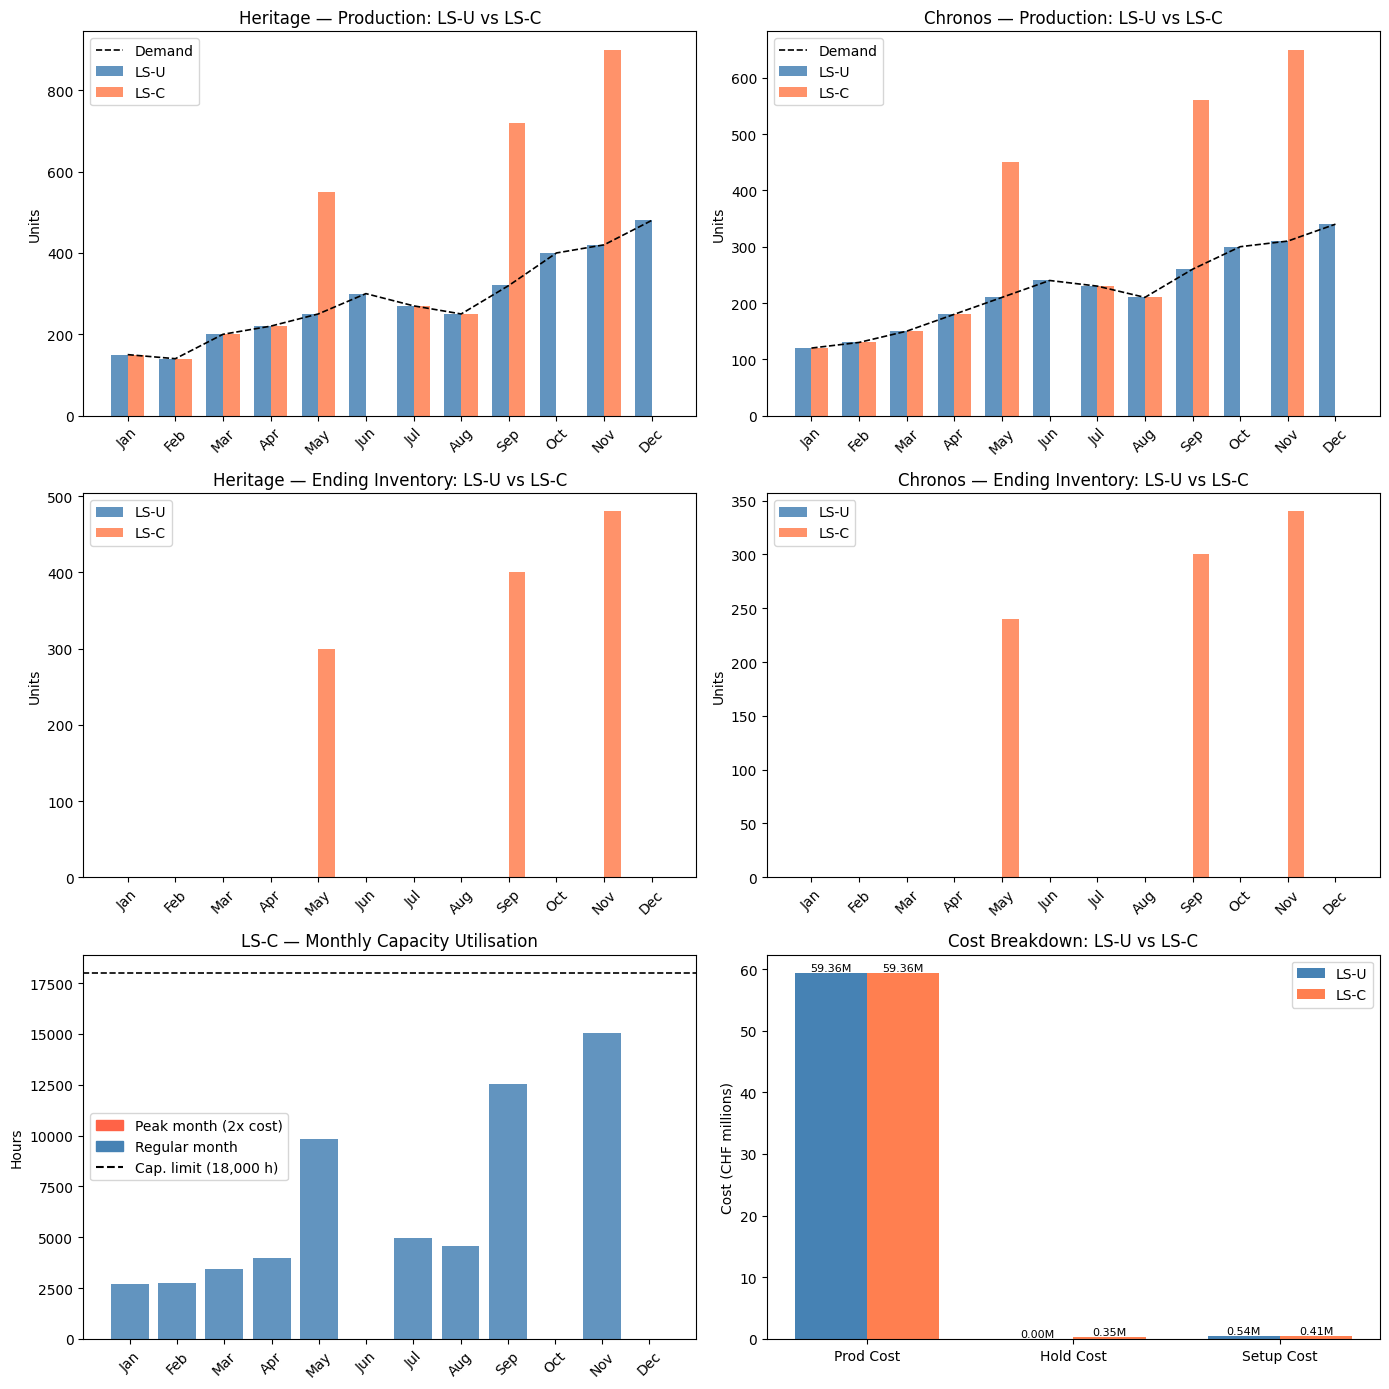

In [21]:
# ── Model LS-C: Capacitated Lot-Sizing (Heritage & Chronos) ──────────────────
#
# Extends LS-U with:
#   1. Capacity constraint: total machine-hours per month <= 18 000 h
#      Heritage: 8 h/unit + 25 h/setup ; Chronos: 12 h/unit + 30 h/setup
#   2. Peak-time cost multiplier alpha[t] = 2 in June, October, December
#      (production & setup costs doubled in those months)
#
# Objective (minimise):
#   sum_{p,t}  alpha[t] * prod_cost[p]  * X[p,t]
# + sum_{p,t}  holding_cost[p] * I[p,t]
# + sum_{p,t}  alpha[t] * setup_cost[p] * Y[p,t]
#
# Additional capacity constraint (for all t):
#   sum_p ( prod_hrs[p]*X[p,t] + setup_hrs[p]*Y[p,t] ) <= 18000
# ─────────────────────────────────────────────────────────────────────────────

from pulp import (
    LpProblem, LpMinimize, LpVariable, LpBinary,
    lpSum, value, PULP_CBC_CMD
)

# ── Capacity & peak parameters ────────────────────────────────────────────────
CAP_HOURS       = 18000
prod_hrs        = {"Heritage": 8,  "Chronos": 12}
setup_hrs       = {"Heritage": 25, "Chronos": 30}
peak_months_set = {6, 10, 12}   # 1-indexed; Jun, Oct, Dec
peak_mult       = {t: (2 if (t + 1) in peak_months_set else 1) for t in range(T2)}


# ── Solver ────────────────────────────────────────────────────────────────────
def solve_lsc(verbose=False):
    """
    Capacitated Lot-Sizing (LS-C) for Heritage and Chronos.
    18 000 h/month capacity constraint; 2x costs in June, October, December.
    """
    prob = LpProblem("Aurelius_LSC", LpMinimize)

    X = {(p,t): LpVariable(f"X_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    I = {(p,t): LpVariable(f"I_{p}_{t}", lowBound=0)
         for p in products2 for t in range(T2)}
    Y = {(p,t): LpVariable(f"Y_{p}_{t}", cat=LpBinary)
         for p in products2 for t in range(T2)}

    # Objective — production & setup costs scaled by peak multiplier
    prob += (
        lpSum(prod_cost2[p]  * peak_mult[t] * X[p,t] for p in products2 for t in range(T2))
      + lpSum(holding_cost2[p]              * I[p,t] for p in products2 for t in range(T2))
      + lpSum(setup_cost2[p] * peak_mult[t] * Y[p,t] for p in products2 for t in range(T2))
    ), "Total_Cost"

    for p in products2:
        for t in range(T2):
            prev_I = 0 if t == 0 else I[p, t-1]
            prob += I[p,t] == prev_I + X[p,t] - demand_p2[p][t], f"inv_{p}_{t}"
            prob += X[p,t] <= BIG_M2[p] * Y[p,t],                f"setup_{p}_{t}"

    # Capacity constraint
    for t in range(T2):
        prob += (
            lpSum(prod_hrs[p] * X[p,t] + setup_hrs[p] * Y[p,t] for p in products2)
            <= CAP_HOURS,
            f"capacity_{t}"
        )

    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # Extract results
    rows = []
    for p in products2:
        for t in range(T2):
            xv = value(X[p,t]); iv = value(I[p,t]); yv = value(Y[p,t])
            pm = peak_mult[t]
            hrs = prod_hrs[p] * xv + setup_hrs[p] * yv
            rows.append({
                "Product":    p,
                "Month":      MONTH_NAMES2[t],
                "Produced":   round(xv, 1),
                "Demand":     demand_p2[p][t],
                "End Inv":    round(iv, 1),
                "Setup":      int(round(yv)),
                "Peak (2x)": "Yes" if pm == 2 else "No",
                "Hrs Used":   round(hrs, 1),
                "Prod Cost":  prod_cost2[p]  * pm * xv,
                "Hold Cost":  holding_cost2[p]    * iv,
                "Setup Cost": setup_cost2[p] * pm * yv,
            })
    df = pd.DataFrame(rows)
    df["Total Cost"] = df["Prod Cost"] + df["Hold Cost"] + df["Setup Cost"]

    df_hrs = (
        df.groupby("Month")["Hrs Used"].sum()
          .reindex(MONTH_NAMES2).reset_index()
    )
    df_hrs.columns = ["Month", "Total Hrs Used"]

    summary = {
        "Status":           prob.status,
        "Total Prod Cost":  sum(prod_cost2[p]    * peak_mult[t] * value(X[p,t]) for p in products2 for t in range(T2)),
        "Total Hold Cost":  sum(holding_cost2[p]               * value(I[p,t]) for p in products2 for t in range(T2)),
        "Total Setup Cost": sum(setup_cost2[p]   * peak_mult[t] * value(Y[p,t]) for p in products2 for t in range(T2)),
        "Grand Total":      value(prob.objective),
    }
    return df, df_hrs, summary


# ── Run & display ─────────────────────────────────────────────────────────────
df_lsc, df_hours, s_lsc = solve_lsc()

print(f"\n{'='*60}")
print(f"  MODEL LS-C — CAPACITATED LOT-SIZING")
print(f"{'='*60}")

for p in products2:
    print(f"\n── {p} ──")
    sub = df_lsc[df_lsc["Product"] == p].drop(columns="Product").reset_index(drop=True)
    display(sub)

print("\n── Monthly Capacity Utilisation ──")
df_cap = df_hours.copy()
df_cap["Capacity"]      = CAP_HOURS
df_cap["Utilisation %"] = (df_cap["Total Hrs Used"] / CAP_HOURS * 100).round(1)
display(df_cap)

print(f"\n── Cost Summary (CHF) ──")
for k, v in s_lsc.items():
    if k == "Status":
        print(f"  {'Status':<22}: {v}")
    else:
        print(f"  {k:<22}: {v:>15,.0f}")

print(f"\n── LS-U vs LS-C Grand Total ──")
print(f"  LS-U : {s_lsu['Grand Total']:>15,.0f} CHF")
print(f"  LS-C : {s_lsc['Grand Total']:>15,.0f} CHF")
print(f"  Diff : {s_lsc['Grand Total'] - s_lsu['Grand Total']:>15,.0f} CHF  (capacity + peak premium)")


# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
x  = range(T2)
w  = 0.35
x1 = [i - w/2 for i in x]
x2 = [i + w/2 for i in x]

for idx, p in enumerate(products2):
    sub_u = df_lsu[df_lsu["Product"] == p].reset_index(drop=True)
    sub_c = df_lsc[df_lsc["Product"] == p].reset_index(drop=True)

    # Production: LS-U vs LS-C
    ax = axes[0, idx]
    ax.bar(x1, sub_u["Produced"], width=w, color="steelblue", label="LS-U", alpha=0.85)
    ax.bar(x2, sub_c["Produced"], width=w, color="coral",     label="LS-C", alpha=0.85)
    ax.plot(x, sub_u["Demand"], "k--", linewidth=1.2, label="Demand")
    ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax.set_ylabel("Units"); ax.set_title(f"{p} — Production: LS-U vs LS-C")
    ax.legend()

    # Inventory: LS-U vs LS-C
    ax2 = axes[1, idx]
    ax2.bar(x1, sub_u["End Inv"], width=w, color="steelblue", label="LS-U", alpha=0.85)
    ax2.bar(x2, sub_c["End Inv"], width=w, color="coral",     label="LS-C", alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax2.set_ylabel("Units"); ax2.set_title(f"{p} — Ending Inventory: LS-U vs LS-C")
    ax2.legend()

# Capacity utilisation
ax3 = axes[2, 0]
bar_cols = ["tomato" if (i+1) in peak_months_set else "steelblue" for i in range(T2)]
ax3.bar(x, df_hours["Total Hrs Used"], color=bar_cols, alpha=0.85)
ax3.axhline(CAP_HOURS, color="black", linestyle="--", linewidth=1.2)
ax3.set_xticks(x); ax3.set_xticklabels(MONTH_NAMES2, rotation=45)
ax3.set_ylabel("Hours"); ax3.set_title("LS-C — Monthly Capacity Utilisation")
peak_patch = mpatches.Patch(color="tomato",    label="Peak month (2x cost)")
reg_patch  = mpatches.Patch(color="steelblue", label="Regular month")
cap_line   = plt.Line2D([0],[0], color="black", linestyle="--", label=f"Cap. limit ({CAP_HOURS:,} h)")
ax3.legend(handles=[peak_patch, reg_patch, cap_line])

# Cost breakdown bar
ax4 = axes[2, 1]
cats  = ["Prod Cost", "Hold Cost", "Setup Cost"]
lsu_v = [s_lsu["Total Prod Cost"], s_lsu["Total Hold Cost"], s_lsu["Total Setup Cost"]]
lsc_v = [s_lsc["Total Prod Cost"], s_lsc["Total Hold Cost"], s_lsc["Total Setup Cost"]]
xi    = np.arange(len(cats))
b1 = ax4.bar(xi - w/2, [v/1e6 for v in lsu_v], w, color="steelblue", label="LS-U")
b2 = ax4.bar(xi + w/2, [v/1e6 for v in lsc_v], w, color="coral",     label="LS-C")
for bar in list(b1) + list(b2):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.2f}M", ha="center", va="bottom", fontsize=8)
ax4.set_xticks(xi); ax4.set_xticklabels(cats)
ax4.set_ylabel("Cost (CHF millions)"); ax4.set_title("Cost Breakdown: LS-U vs LS-C")
ax4.legend()

plt.tight_layout()
plt.show()


##MRP


  MRP MODEL — MULTI-LEVEL MATERIAL REQUIREMENTS PLANNING

── Finished Goods Production Plan ──

   Heritage


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,490,150,340,1,"3,920,000","51,000","20,000","3,991,000"
1,Feb,0,140,200,0,0,"30,000",0,"30,000"
2,Mar,0,200,0,0,0,0,0,0
3,Apr,470,220,250,1,"3,760,000","37,500","20,000","3,817,500"
4,May,0,250,0,0,0,0,0,0
5,Jun,820,300,520,1,"6,560,000","78,000","20,000","6,658,000"
6,Jul,0,270,250,0,0,"37,500",0,"37,500"
7,Aug,0,250,0,0,0,0,0,0
8,Sep,720,320,400,1,"5,760,000","60,000","20,000","5,840,000"
9,Oct,0,400,0,0,0,0,0,0



   Chronos


,Month,Produced,Demand,End Inv,Setup,Prod Cost,Hold Cost,Setup Cost,Total Cost
0,Jan,400,120,280,1,"4,800,000","56,000","25,000","4,881,000"
1,Feb,0,130,150,0,0,"30,000",0,"30,000"
2,Mar,0,150,0,0,0,0,0,0
3,Apr,390,180,210,1,"4,680,000","42,000","25,000","4,747,000"
4,May,0,210,0,0,0,0,0,0
5,Jun,680,240,440,1,"8,160,000","88,000","25,000","8,273,000"
6,Jul,0,230,210,0,0,"42,000",0,"42,000"
7,Aug,0,210,0,0,0,0,0,0
8,Sep,560,260,300,1,"6,720,000","60,000","25,000","6,805,000"
9,Oct,0,300,0,0,0,0,0,0



── Component Order & Inventory Plan ──

   3235 Movement  (LT: 2 mo, Init. stock: 900)


...


   Lubricant Oil  (LT: 1 mo, Init. stock: 550)


,Month,Order Placed,End Inv,Hold Cost
0,Jan,0,0,0
1,Feb,0,0,0
2,Mar,"8,600",0,0
3,Apr,0,0,0
4,May,"15,000",0,0
5,Jun,0,0,0
6,Jul,0,0,0
7,Aug,"12,800",0,0
8,Sep,0,0,0
9,Oct,"15,500",0,0



   Gold Crown  (LT: 1 mo, Init. stock: 300)


,Month,Order Placed,End Inv,Hold Cost
0,Jan,0,0,0
1,Feb,0,0,0
2,Mar,470,0,0
3,Apr,0,0,0
4,May,820,0,0
5,Jun,0,0,0
6,Jul,0,0,0
7,Aug,720,0,0
8,Sep,0,0,0
9,Oct,900,0,0



── Cost Summary (CHF) ──
  Status                : 1
  FG Prod Cost          :      59,360,000
  FG Hold Cost          :         752,000
  FG Setup Cost         :         225,000
  Comp Proc Cost        :      73,662,000
  Comp Hold Cost        :         135,720
  Comp Setup Cost       :         840,000
  Grand Total           :     134,974,720

── External Demand Trade-off (Oystersteel Case) ──
  Total external demand months 1-6: 118 units
  All external demand is satisfied by the MRP plan.
  Component orders are front-loaded to buffer both internal assembly
  and external client requirements without shortages.


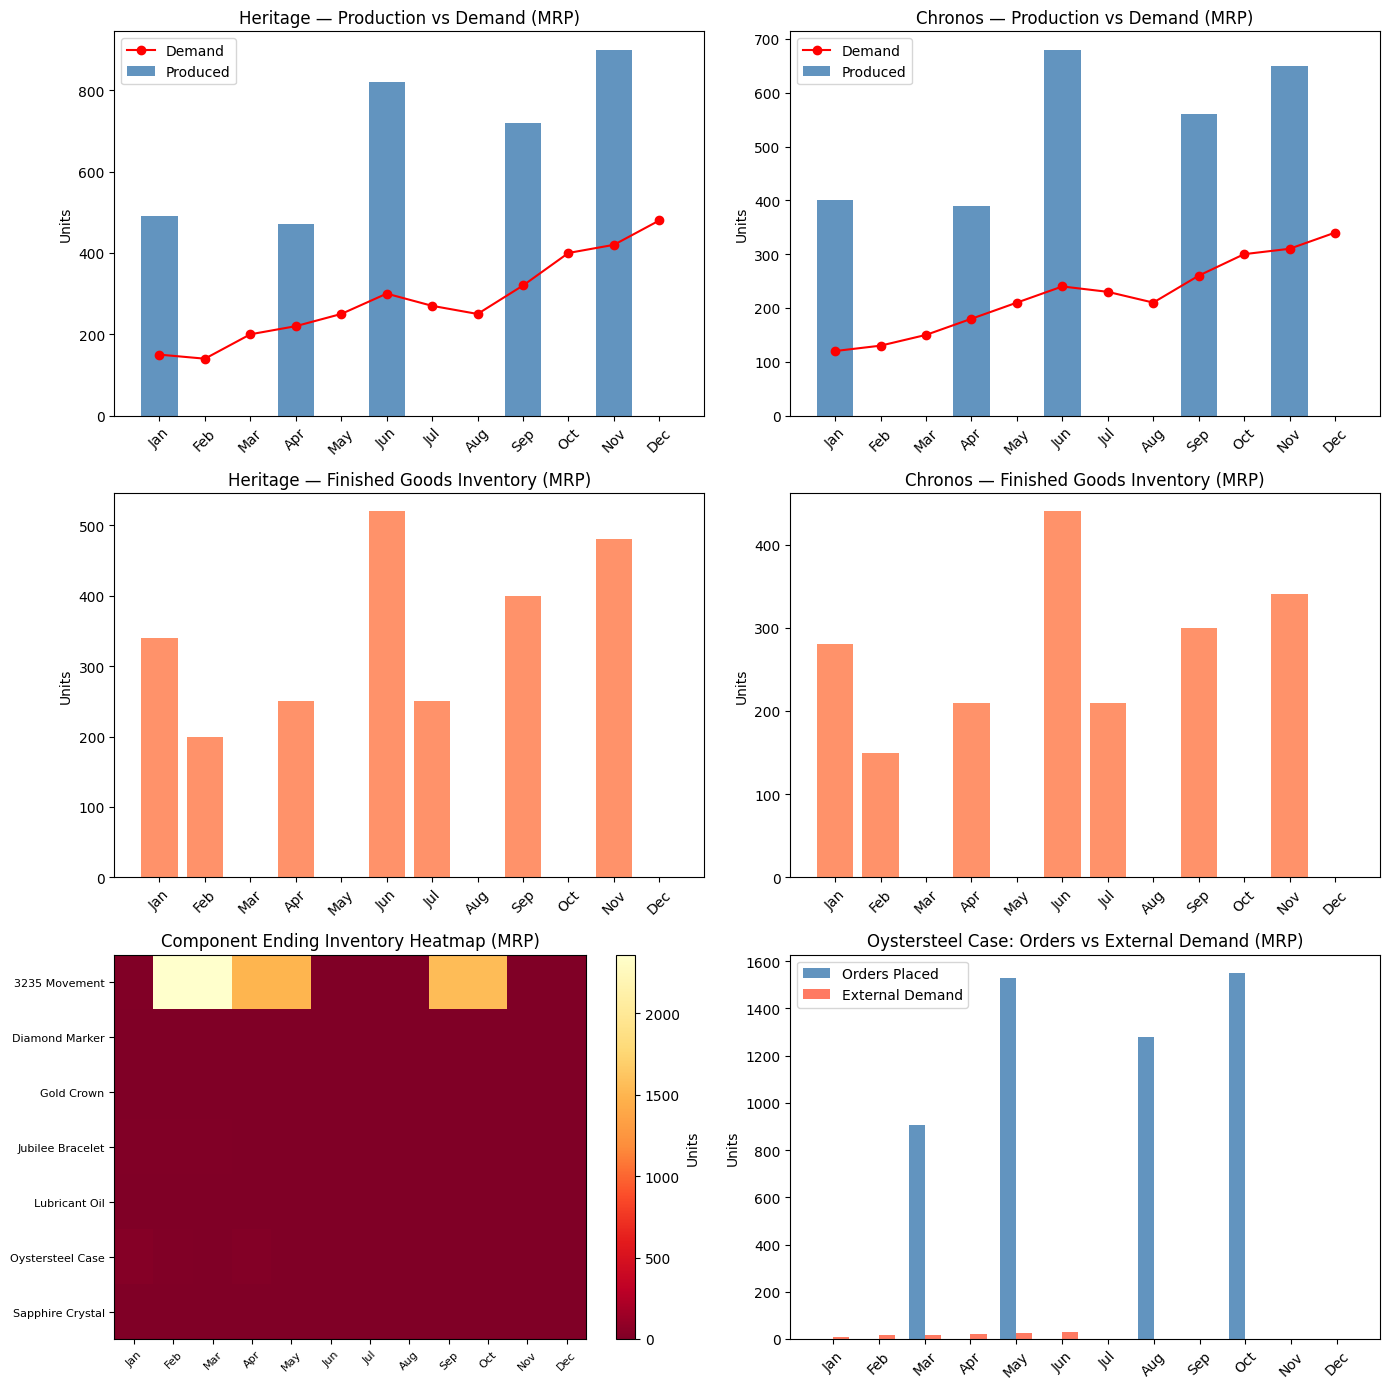

In [22]:
# ── MRP Model: Multi-Level Material Requirements Planning ────────────────────
#
# Simultaneously plans finished goods (Heritage, Chronos) AND all 7 components
# from the Bill of Materials, respecting lead times, initial inventories,
# and external demand for Oystersteel Cases (months 1-6).
#
# Decision variables:
#   Xfg[p,t]  : finished-good production quantity            (>= 0)
#   Ifg[p,t]  : finished-good ending inventory               (>= 0)
#   Yfg[p,t]  : binary setup for finished good               (in {0,1})
#   Qc[c,t]   : component order qty placed in month t        (>= 0)
#   Ic[c,t]   : component ending inventory                   (>= 0)
#   Yc[c,t]   : binary setup for component order             (in {0,1})
#
# Key component inventory balance:
#   Ic[c,t] = Ic[c,t-1] + Qc[c, t-LT_c] - sum_p bom[c,p]*Xfg[p,t] - ext[c,t]
#   (order placed LT_c months ago arrives and is consumed this period)
# ─────────────────────────────────────────────────────────────────────────────

from pulp import (
    LpProblem, LpMinimize, LpVariable, LpBinary,
    lpSum, value, PULP_CBC_CMD
)

# ── BOM & component parameters ────────────────────────────────────────────────
bom = {
    "3235 Movement":    {"Heritage": 1,  "Chronos":  1},
    "Oystersteel Case": {"Heritage": 1,  "Chronos":  1},
    "Sapphire Crystal": {"Heritage": 1,  "Chronos":  1},
    "Jubilee Bracelet": {"Heritage": 1,  "Chronos":  0},
    "Diamond Marker":   {"Heritage": 0,  "Chronos":  8},
    "Lubricant Oil":    {"Heritage": 10, "Chronos": 10},  # 10-gram units
    "Gold Crown":       {"Heritage": 1,  "Chronos":  0},
}

lead_time_mo = {
    "3235 Movement": 2, "Oystersteel Case": 1, "Sapphire Crystal": 1,
    "Jubilee Bracelet": 2, "Diamond Marker": 2, "Lubricant Oil": 1, "Gold Crown": 1,
}

init_stock = {
    "3235 Movement": 900, "Oystersteel Case": 550, "Sapphire Crystal": 550,
    "Jubilee Bracelet": 500, "Diamond Marker": 3200, "Lubricant Oil": 550 #10-gram units still
    ,
    "Gold Crown": 300,
}

comp_prod_cost2    = {
    "3235 Movement": 6500, "Oystersteel Case": 2000, "Sapphire Crystal": 1500,
    "Jubilee Bracelet": 1800, "Diamond Marker": 400, "Lubricant Oil": 100,
    "Gold Crown": 600,
}
comp_holding_cost2 = {
    "3235 Movement": 12, "Oystersteel Case": 60, "Sapphire Crystal": 80,
    "Jubilee Bracelet": 40, "Diamond Marker": 25, "Lubricant Oil": 3,
    "Gold Crown": 20,
}
comp_setup_cost2   = {
    "3235 Movement": 80000, "Oystersteel Case": 50000, "Sapphire Crystal": 50000,
    "Jubilee Bracelet": 35000, "Diamond Marker": 20000, "Lubricant Oil": 10000,
    "Gold Crown": 25000,
}

# External demand for Oystersteel Cases (months 1-6; 0 thereafter)
ext_demand_oyster  = [10, 15, 18, 22, 25, 28] + [0] * 6

components = list(bom.keys())
max_lt     = max(lead_time_mo.values())   # = 2

# Big-M for finished goods and components
BIG_M_fg = {p: sum(demand_p2[p]) + 1 for p in products2}
BIG_M_c  = {
    c: sum(bom[c][p] * sum(demand_p2[p]) for p in products2 if bom[c][p] > 0)
       + init_stock[c] + 1
    for c in components
}


# ── Solver ────────────────────────────────────────────────────────────────────
def solve_mrp(verbose=False):
    """
    Full multi-level MRP MILP.
    Orders are placed from index -1 onward so 2-month-lead-time components
    can be ordered in month -1 and arrive ready for month 1 consumption.
    """
    prob = LpProblem("Aurelius_MRP", LpMinimize)

    # Order range: allows negative indices for pre-horizon orders
    order_range = range(-max_lt + 1, T2)   # -1, 0, ..., 11

    # ── Decision variables ────────────────────────────────────────────────────
    Xfg = {(p,t): LpVariable(f"Xfg_{p}_{t}", lowBound=0)
           for p in products2 for t in range(T2)}
    Ifg = {(p,t): LpVariable(f"Ifg_{p}_{t}", lowBound=0)
           for p in products2 for t in range(T2)}
    Yfg = {(p,t): LpVariable(f"Yfg_{p}_{t}", cat=LpBinary)
           for p in products2 for t in range(T2)}

    Qc  = {(c,t): LpVariable(f"Q_{c}_{t}", lowBound=0)
           for c in components for t in order_range}
    Ic  = {(c,t): LpVariable(f"Ic_{c}_{t}", lowBound=0)
           for c in components for t in range(T2)}
    Yc  = {(c,t): LpVariable(f"Yc_{c}_{t}", cat=LpBinary)
           for c in components for t in order_range}

    # ── Objective ─────────────────────────────────────────────────────────────
    prob += (
        # Finished goods
        lpSum(prod_cost2[p]    * Xfg[p,t] for p in products2 for t in range(T2))
      + lpSum(holding_cost2[p] * Ifg[p,t] for p in products2 for t in range(T2))
      + lpSum(setup_cost2[p]   * Yfg[p,t] for p in products2 for t in range(T2))
        # Components
      + lpSum(comp_prod_cost2[c]    * Qc[c,t]  for c in components for t in order_range)
      + lpSum(comp_holding_cost2[c] * Ic[c,t]  for c in components for t in range(T2))
      + lpSum(comp_setup_cost2[c]   * Yc[c,t]  for c in components for t in order_range)
    ), "Total_Cost"

    # ── Finished goods constraints ────────────────────────────────────────────
    for p in products2:
        for t in range(T2):
            prev_Ifg = 0 if t == 0 else Ifg[p, t-1]
            prob += Ifg[p,t] == prev_Ifg + Xfg[p,t] - demand_p2[p][t], f"inv_fg_{p}_{t}"
            prob += Xfg[p,t] <= BIG_M_fg[p] * Yfg[p,t],               f"setup_fg_{p}_{t}"

    # ── Component constraints ─────────────────────────────────────────────────
    for c in components:
        lt = lead_time_mo[c]
        for t in range(T2):
            # Dependent demand: BOM * finished-good production this period
            gross_req = lpSum(bom[c][p] * Xfg[p,t] for p in products2)
            # External demand (Oystersteel only)
            ext = ext_demand_oyster[t] if c == "Oystersteel Case" else 0
            # Receipt from order placed lt months ago
            ord_idx = t - lt
            receipt = Qc[c, ord_idx] if ord_idx in order_range else 0
            # Inventory balance
            prev_Ic = init_stock[c] if t == 0 else Ic[c, t-1]
            prob += Ic[c,t] == prev_Ic + receipt - gross_req - ext, f"inv_comp_{c}_{t}"
            # Setup linking for orders placed this period
            if t in order_range:
                prob += Qc[c,t] <= BIG_M_c[c] * Yc[c,t], f"setup_comp_{c}_{t}"

    prob.solve(PULP_CBC_CMD(msg=1 if verbose else 0))

    # ── Extract finished goods results ────────────────────────────────────────
    fg_rows = []
    for p in products2:
        for t in range(T2):
            fg_rows.append({
                "Product":    p, "Month": MONTH_NAMES2[t],
                "Produced":   round(value(Xfg[p,t]), 1),
                "Demand":     demand_p2[p][t],
                "End Inv":    round(value(Ifg[p,t]), 1),
                "Setup":      int(round(value(Yfg[p,t]))),
                "Prod Cost":  prod_cost2[p]    * value(Xfg[p,t]),
                "Hold Cost":  holding_cost2[p] * value(Ifg[p,t]),
                "Setup Cost": setup_cost2[p]   * value(Yfg[p,t]),
            })
    df_fg = pd.DataFrame(fg_rows)
    df_fg["Total Cost"] = df_fg["Prod Cost"] + df_fg["Hold Cost"] + df_fg["Setup Cost"]

    # ── Extract component results ─────────────────────────────────────────────
    comp_rows = []
    for c in components:
        for t in range(T2):
            q_val = value(Qc[c, t]) if t in order_range else 0.0
            comp_rows.append({
                "Component":    c, "Month": MONTH_NAMES2[t],
                "Order Placed": round(q_val, 1),
                "End Inv":      round(value(Ic[c, t]), 1),
                "Hold Cost":    comp_holding_cost2[c] * value(Ic[c, t]),
            })
    df_comp = pd.DataFrame(comp_rows)

    summary = {
        "Status":           prob.status,
        "FG Prod Cost":     sum(prod_cost2[p]         * value(Xfg[p,t]) for p in products2  for t in range(T2)),
        "FG Hold Cost":     sum(holding_cost2[p]      * value(Ifg[p,t]) for p in products2  for t in range(T2)),
        "FG Setup Cost":    sum(setup_cost2[p]        * value(Yfg[p,t]) for p in products2  for t in range(T2)),
        "Comp Proc Cost":   sum(comp_prod_cost2[c]    * value(Qc[c,t])  for c in components for t in order_range),
        "Comp Hold Cost":   sum(comp_holding_cost2[c] * value(Ic[c,t])  for c in components for t in range(T2)),
        "Comp Setup Cost":  sum(comp_setup_cost2[c]   * value(Yc[c,t])  for c in components for t in order_range),
        "Grand Total":      value(prob.objective),
    }
    return df_fg, df_comp, summary


# ── Run & display ─────────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:,.0f}".format)

df_fg_mrp, df_comp_mrp, s_mrp = solve_mrp()

print(f"\n{'='*60}")
print(f"  MRP MODEL — MULTI-LEVEL MATERIAL REQUIREMENTS PLANNING")
print(f"{'='*60}")

print("\n── Finished Goods Production Plan ──")
for p in products2:
    print(f"\n   {p}")
    sub = df_fg_mrp[df_fg_mrp["Product"] == p].drop(columns="Product").reset_index(drop=True)
    display(sub)

print("\n── Component Order & Inventory Plan ──")
for c in components:
    lt = lead_time_mo[c]; s0 = init_stock[c]
    print(f"\n   {c}  (LT: {lt} mo, Init. stock: {s0:,})")
    sub = df_comp_mrp[df_comp_mrp["Component"] == c].drop(columns="Component").reset_index(drop=True)
    display(sub)

print(f"\n── Cost Summary (CHF) ──")
for k, v in s_mrp.items():
    if k == "Status":
        print(f"  {'Status':<22}: {v}")
    else:
        print(f"  {k:<22}: {v:>15,.0f}")

print(f"\n── External Demand Trade-off (Oystersteel Case) ──")
print(f"  Total external demand months 1-6: {sum(ext_demand_oyster)} units")
print(f"  All external demand is satisfied by the MRP plan.")
print(f"  Component orders are front-loaded to buffer both internal assembly")
print(f"  and external client requirements without shortages.")


# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
x = range(T2)
w = 0.35

# FG production & inventory
for idx, p in enumerate(products2):
    sub = df_fg_mrp[df_fg_mrp["Product"] == p].reset_index(drop=True)

    ax = axes[0, idx]
    ax.bar(x, sub["Produced"], color="steelblue", alpha=0.85, label="Produced")
    ax.plot(x, sub["Demand"],  "ro-", linewidth=1.5, label="Demand")
    ax.set_xticks(x); ax.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax.set_ylabel("Units"); ax.set_title(f"{p} — Production vs Demand (MRP)")
    ax.legend()

    ax2 = axes[1, idx]
    ax2.bar(x, sub["End Inv"], color="coral", alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES2, rotation=45)
    ax2.set_ylabel("Units"); ax2.set_title(f"{p} — Finished Goods Inventory (MRP)")

# Component inventory heatmap
ax3 = axes[2, 0]
pivot = df_comp_mrp.pivot(index="Component", columns="Month", values="End Inv")[MONTH_NAMES2]
im = ax3.imshow(pivot.values, aspect="auto", cmap="YlOrRd_r")
ax3.set_xticks(range(T2)); ax3.set_xticklabels(MONTH_NAMES2, rotation=45, fontsize=8)
ax3.set_yticks(range(len(components))); ax3.set_yticklabels(pivot.index, fontsize=8)
ax3.set_title("Component Ending Inventory Heatmap (MRP)")
plt.colorbar(im, ax=ax3, label="Units")

# Oystersteel: orders placed vs external demand
ax4 = axes[2, 1]
oyster = df_comp_mrp[df_comp_mrp["Component"] == "Oystersteel Case"].reset_index(drop=True)
x1c = [i - w/2 for i in x]; x2c = [i + w/2 for i in x]
ax4.bar(x1c, oyster["Order Placed"], width=w, color="steelblue", alpha=0.85, label="Orders Placed")
ax4.bar(x2c, ext_demand_oyster,      width=w, color="tomato",    alpha=0.85, label="External Demand")
ax4.set_xticks(x); ax4.set_xticklabels(MONTH_NAMES2, rotation=45)
ax4.set_ylabel("Units"); ax4.set_title("Oystersteel Case: Orders vs External Demand (MRP)")
ax4.legend()

plt.tight_layout()
plt.show()


#**Part 3**

##Base model



  BASELINE SCHEDULE

Status: 1  |  Cmax: 45.5 hrs

── Order-Level KPIs ──


,Order,Due,Completion,Tardiness
0,O01,40,39,0
1,O02,40,34,0
2,O03,30,20,0
3,O04,40,18,0
4,O05,50,46,0



── Station Utilisation ──


,Station,Machines,Busy (hrs),Capacity (hrs),Utilisation %
0,Assembly,2,44,91,48
1,Crystal,1,12,46,26
2,Bracelet,1,2,46,4
3,Marker,1,12,46,26
4,Inspection,1,28,46,62


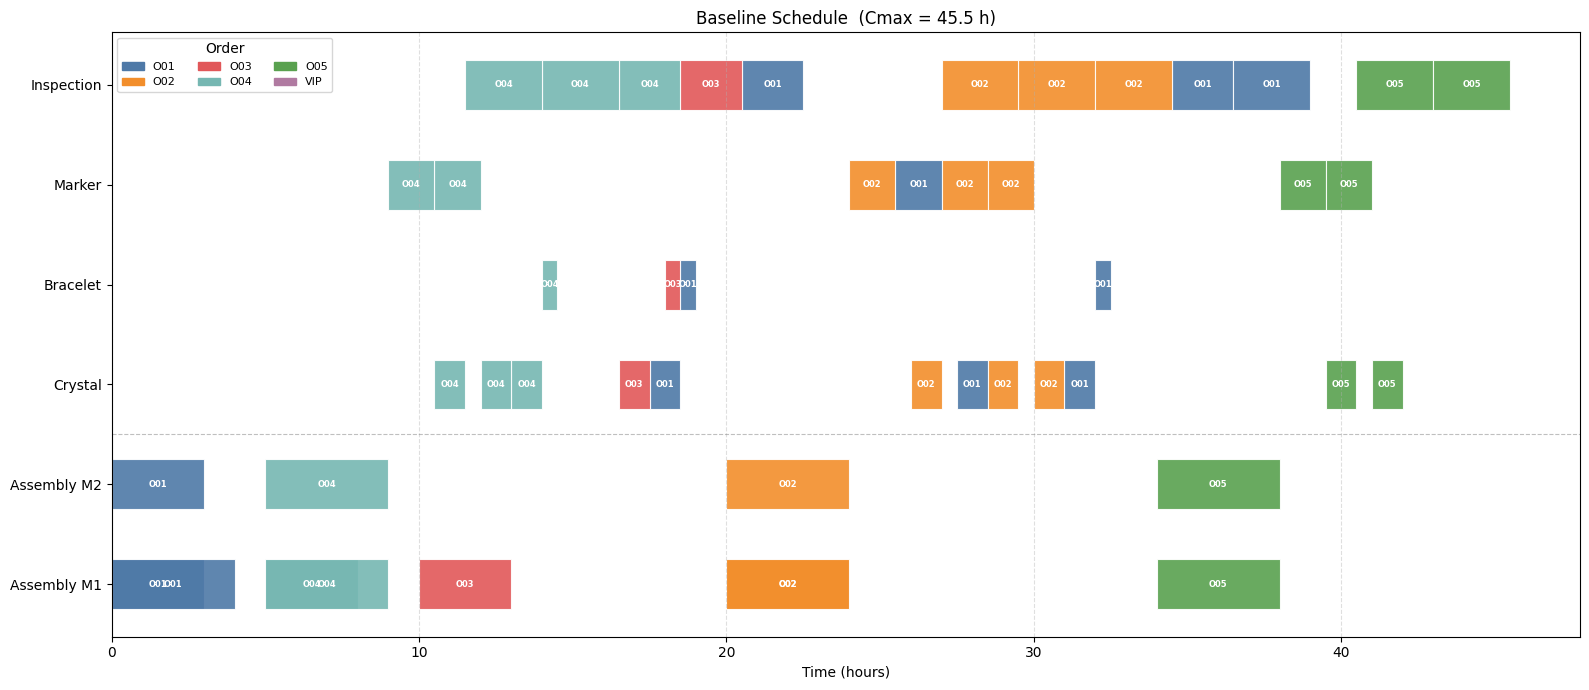

In [30]:
# ── Part 3: Scheduling — Aurelius SA Workshop ─────────────────────────────────
#
# Flexible job-shop MILP scheduling Heritage & Chronos watches across 5 stations.
#
# Decision variables:
#   S[j,o]       : start time of operation o of job j               (>= 0)
#   C[j]         : completion time of job j                         (>= 0)
#   T[j]         : tardiness of job j = max(0, C[j] - due[j])       (>= 0)
#   Cmax         : makespan = max completion time                    (>= 0)
#   delta[j1,o1,j2,o2] : 1 if op(j1,o1) precedes op(j2,o2) on same station
#   mach[j,o]    : Assembly machine assignment (0 or 1)             binary
#
# Objective (minimise):
#   sum_j  w[j] * T[j]  +  0.01 * Cmax
#   where w[j] = priority weight (priority 1->3, 2->2, 3->1)
#
# Constraints:
#   Release time  : S[j,0] >= r[j]
#   Precedence    : S[j,o+1] >= S[j,o] + dur[j,o]   (or == for zero-wait)
#   Completion    : C[j] == S[j,last] + dur[j,last]
#   Tardiness     : T[j] >= C[j] - d[j]
#   No-overlap    : big-M disjunctive constraints per station
#   Assembly      : two-machine assignment + disjunctive per machine
# ─────────────────────────────────────────────────────────────────────────────


# ── Problem data ──────────────────────────────────────────────────────────────
stations = {
    "Assembly":   2,
    "Crystal":    1,
    "Bracelet":   1,
    "Marker":     1,
    "Inspection": 1,
}

routing = {
    "Heritage": [
        ("Assembly",   3.0),
        ("Crystal",    1.0),
        ("Bracelet",   0.5),
        ("Inspection", 2.0),
    ],
    "Chronos": [
        ("Assembly",   4.0),
        ("Marker",     1.5),
        ("Crystal",    1.0),
        ("Inspection", 2.5),
    ],
}

orders_data = {
    "O01": {"watches": [("Heritage", 2), ("Chronos", 1)], "release":  0, "due": 40, "priority": 2},
    "O02": {"watches": [("Chronos",  3)],                  "release": 20, "due": 40, "priority": 1},
    "O03": {"watches": [("Heritage", 1)],                  "release": 10, "due": 30, "priority": 3},
    "O04": {"watches": [("Heritage", 1), ("Chronos", 2)],  "release":  5, "due": 40, "priority": 1},
    "O05": {"watches": [("Chronos",  2)],                  "release": 34, "due": 50, "priority": 2},
}

priority_weight = {1: 3, 2: 2, 3: 1}
BIG_M = 200


# ── Job expansion: one job per watch unit ─────────────────────────────────────
def expand_jobs(orders):
    jobs = []
    for oid, od in orders.items():
        for wtype, qty in od["watches"]:
            for k in range(qty):
                jobs.append({
                    "job":      f"{oid}_{wtype}_{k+1}",
                    "order":    oid,
                    "type":     wtype,
                    "release":  od["release"],
                    "due":      od["due"],
                    "priority": od["priority"],
                    "routing":  routing[wtype],
                })
    return jobs

base_jobs = expand_jobs(orders_data)


# ── MILP solver ───────────────────────────────────────────────────────────────
def solve_schedule(jobs, zero_wait=False, cleaning=False,
                   crystal_breakdown=None, vip_job=None, verbose=False):
    """
    Flexible job-shop MILP for Aurelius SA workshop.

    Parameters
    ----------
    zero_wait         : no waiting between consecutive ops (Scenario A)
    cleaning          : 0.5h cleaning when consecutive ops on a station
                        are from different watch types (Scenario B)
    crystal_breakdown : (start_hr, end_hr) Crystal station offline (Scenario C)
    vip_job           : extra job dict to insert (Scenario D)
    """
    all_jobs = list(jobs) + ([vip_job] if vip_job else [])
    J = len(all_jobs)

    prob = LpProblem("Aurelius_Schedule", LpMinimize)

    # Decision variables
    S      = {(j, o): LpVariable(f"S_{j}_{o}", lowBound=0)
              for j in range(J) for o in range(len(all_jobs[j]["routing"]))}
    C      = {j: LpVariable(f"C_{j}", lowBound=0) for j in range(J)}
    T_tard = {j: LpVariable(f"T_{j}", lowBound=0) for j in range(J)}
    Cmax   = LpVariable("Cmax", lowBound=0)

    # Station-conflict pairs
    pairs = [
        (j1, o1, j2, o2, st1)
        for j1 in range(J) for o1, (st1, _) in enumerate(all_jobs[j1]["routing"])
        for j2 in range(J) for o2, (st2, _) in enumerate(all_jobs[j2]["routing"])
        if j1 < j2 and st1 == st2
    ]
    delta = {(j1, o1, j2, o2): LpVariable(f"d_{j1}_{o1}_{j2}_{o2}", cat=LpBinary)
             for j1, o1, j2, o2, _ in pairs}

    # Assembly machine assignment
    asm_ops = [(j, o) for j in range(J)
               for o, (st, _) in enumerate(all_jobs[j]["routing"]) if st == "Assembly"]
    mach = {(j, o): LpVariable(f"m_{j}_{o}", cat=LpBinary) for j, o in asm_ops}

    # Objective: weighted tardiness + small Cmax penalty
    prob += (
        lpSum(priority_weight[all_jobs[j]["priority"]] * T_tard[j] for j in range(J))
        + 0.01 * Cmax
    ), "Obj"

    # Constraints
    for j in range(J):
        job   = all_jobs[j]
        n_ops = len(job["routing"])

        prob += S[j, 0] >= job["release"], f"release_{j}"

        for o, (st, dur) in enumerate(job["routing"]):
            if o < n_ops - 1:
                if zero_wait:
                    prob += S[j, o+1] == S[j, o] + dur, f"zwait_{j}_{o}"
                else:
                    prob += S[j, o+1] >= S[j, o] + dur, f"prec_{j}_{o}"

        last_dur = job["routing"][-1][1]
        prob += C[j] == S[j, n_ops-1] + last_dur, f"comp_{j}"
        prob += T_tard[j] >= C[j] - job["due"],    f"tard_{j}"
        prob += Cmax >= C[j],                       f"cmax_{j}"

    # No-overlap disjunctive constraints
    for j1, o1, j2, o2, st in pairs:
        dur1  = all_jobs[j1]["routing"][o1][1]
        dur2  = all_jobs[j2]["routing"][o2][1]
        clean = (0.5 if cleaning and all_jobs[j1]["type"] != all_jobs[j2]["type"] else 0)
        d     = delta[j1, o1, j2, o2]

        if st == "Assembly":
            same = LpVariable(f"same_{j1}_{o1}_{j2}_{o2}", cat=LpBinary)
            prob += mach[j1,o1] - mach[j2,o2] <=  (1-same), f"sm1_{j1}_{o1}_{j2}_{o2}"
            prob += mach[j2,o2] - mach[j1,o1] <=  (1-same), f"sm2_{j1}_{o1}_{j2}_{o2}"
            prob += S[j2,o2] >= S[j1,o1] + dur1 + clean - BIG_M*(1-d) - BIG_M*(1-same), \
                   f"asm1_{j1}_{o1}_{j2}_{o2}"
            prob += S[j1,o1] >= S[j2,o2] + dur2 + clean - BIG_M*d     - BIG_M*(1-same), \
                   f"asm2_{j1}_{o1}_{j2}_{o2}"
        else:
            prob += S[j2,o2] >= S[j1,o1] + dur1 + clean - BIG_M*(1-d), \
                   f"no1_{j1}_{o1}_{j2}_{o2}"
            prob += S[j1,o1] >= S[j2,o2] + dur2 + clean - BIG_M*d,     \
                   f"no2_{j1}_{o1}_{j2}_{o2}"

    # Crystal Fitting breakdown window
    if crystal_breakdown:
        bd_s, bd_e = crystal_breakdown
        for j in range(J):
            for o, (st, dur) in enumerate(all_jobs[j]["routing"]):
                if st == "Crystal":
                    bf = LpVariable(f"bd_{j}_{o}", cat=LpBinary)
                    prob += S[j,o] + dur <= bd_s + BIG_M*(1-bf), f"bd_b_{j}_{o}"
                    prob += S[j,o]       >= bd_e - BIG_M*bf,     f"bd_a_{j}_{o}"

    prob.solve(PULP_CBC_CMD(msg=0 if not verbose else 1))

    # Extract schedule
    rows = []
    for j, job in enumerate(all_jobs):
        for o, (st, dur) in enumerate(job["routing"]):
            sv = value(S[j, o])
            rows.append({
                "job":      job["job"],
                "order":    job["order"],
                "type":     job["type"],
                "station":  st,
                "op":       o,
                "start":    round(sv, 3),
                "end":      round(sv + dur, 3),
                "duration": dur,
            })
    df_sched = pd.DataFrame(rows)

    # Job-level KPIs
    kpi_rows = []
    for j, job in enumerate(all_jobs):
        kpi_rows.append({
            "job":       job["job"],
            "order":     job["order"],
            "release":   job["release"],
            "due":       job["due"],
            "priority":  job["priority"],
            "Cj":        round(value(C[j]), 2),
            "Tardiness": round(value(T_tard[j]), 2),
        })
    df_kpi = pd.DataFrame(kpi_rows)

    # Order-level KPIs
    order_kpi = []
    for oid in df_kpi["order"].unique():
        sub      = df_kpi[df_kpi["order"] == oid]
        cmax_ord = sub["Cj"].max()
        due      = sub["due"].iloc[0]
        order_kpi.append({
            "Order":      oid,
            "Due":        due,
            "Completion": round(cmax_ord, 2),
            "Tardiness":  round(max(0, cmax_ord - due), 2),
        })
    df_order_kpi = pd.DataFrame(order_kpi)

    return df_sched, df_kpi, df_order_kpi, round(value(Cmax), 2), prob.status


# ── Gantt chart helper ────────────────────────────────────────────────────────
def plot_gantt(df_sched, title="Gantt Chart", crystal_breakdown=None):
    order_colors = {
        "O01": "#4e79a7", "O02": "#f28e2b", "O03": "#e15759",
        "O04": "#76b7b2", "O05": "#59a14f", "VIP": "#b07aa1",
    }

    # ── Assign Assembly ops to machine 0 or 1 greedily (no overlap) ──────────
    asm_ops = df_sched[df_sched["station"] == "Assembly"].sort_values("start").copy()
    machine_end = [0.0, 0.0]   # earliest free time for each Assembly machine
    machine_assign = {}
    for idx, row in asm_ops.iterrows():
        # Assign to the machine that is free earliest and doesn't overlap
        if machine_end[0] <= row["start"]:
            machine_assign[idx] = 0
            machine_end[0] = row["end"]
        elif machine_end[1] <= row["start"]:
            machine_assign[idx] = 1
            machine_end[1] = row["end"]
        else:
            # Both busy — assign to the one that frees up first
            m = 0 if machine_end[0] <= machine_end[1] else 1
            machine_assign[idx] = m
            machine_end[m] = row["end"]

    # ── Build y-axis rows ─────────────────────────────────────────────────────
    # Assembly Machine 1 and 2 get separate rows; other stations one row each
    row_labels = [
        "Assembly M1",
        "Assembly M2",
        "Crystal",
        "Bracelet",
        "Marker",
        "Inspection",
    ]
    y_pos = {label: i for i, label in enumerate(row_labels)}

    fig, ax = plt.subplots(figsize=(16, 7))

    for _, row in df_sched.iterrows():
        if row["station"] == "Assembly":
            m   = machine_assign.get(_, 0)
            y   = y_pos[f"Assembly M{m + 1}"]
        else:
            y   = y_pos.get(row["station"], len(row_labels))

        col = order_colors.get(row["order"], "#aaaaaa")
        ax.barh(y, row["end"] - row["start"], left=row["start"],
                height=0.5, color=col, edgecolor="white", linewidth=0.8, alpha=0.9)
        ax.text(row["start"] + (row["end"] - row["start"]) / 2, y,
                row["job"].split("_")[0], ha="center", va="center",
                fontsize=6, color="white", fontweight="bold")

    if crystal_breakdown:
        bd_s, bd_e = crystal_breakdown
        ax.axvspan(bd_s, bd_e, color="red", alpha=0.1, label="Crystal offline")

    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_xlabel("Time (hours)")
    ax.set_title(title)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    # Separator line between the two Assembly rows and the rest
    ax.axhline(1.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

    legend_patches = [mpatches.Patch(color=c, label=o) for o, c in order_colors.items()]
    ax.legend(handles=legend_patches, loc="upper left", fontsize=8, ncol=3, title="Order")
    plt.tight_layout()
    plt.show()


# ── Station utilisation helper ────────────────────────────────────────────────
def station_utilisation(df_sched, cmax):
    util = []
    for st in ["Assembly", "Crystal", "Bracelet", "Marker", "Inspection"]:
        sub  = df_sched[df_sched["station"] == st]
        busy = sub["duration"].sum()
        cap  = stations[st] * cmax
        util.append({
            "Station":        st,
            "Machines":       stations[st],
            "Busy (hrs)":     round(busy, 2),
            "Capacity (hrs)": round(cap, 2),
            "Utilisation %":  round(busy / cap * 100, 1),
        })
    return pd.DataFrame(util)


# ═══════════════════════════════════════════════════════════════════════════════
# BASELINE SCHEDULE
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  BASELINE SCHEDULE")
print(f"{'='*60}")

df_base, df_kpi_base, df_ord_base, cmax_base, status_base = solve_schedule(base_jobs)

print(f"\nStatus: {status_base}  |  Cmax: {cmax_base} hrs")
print("\n── Order-Level KPIs ──")
display(df_ord_base)
print("\n── Station Utilisation ──")
display(station_utilisation(df_base, cmax_base))
plot_gantt(df_base, title=f"Baseline Schedule  (Cmax = {cmax_base} h)")


##Scenario A



  SCENARIO A — ZERO-WAIT POLICY
Cmax baseline: 45.5 h  →  Cmax zero-wait: 45.5 h  (Delta = 0.0 h)

── Order-Level KPIs (Scenario A) ──


,Order,Due,Completion,Tardiness
0,O01,40,38,0
1,O02,40,34,0
2,O03,30,20,0
3,O04,40,18,0
4,O05,50,46,0


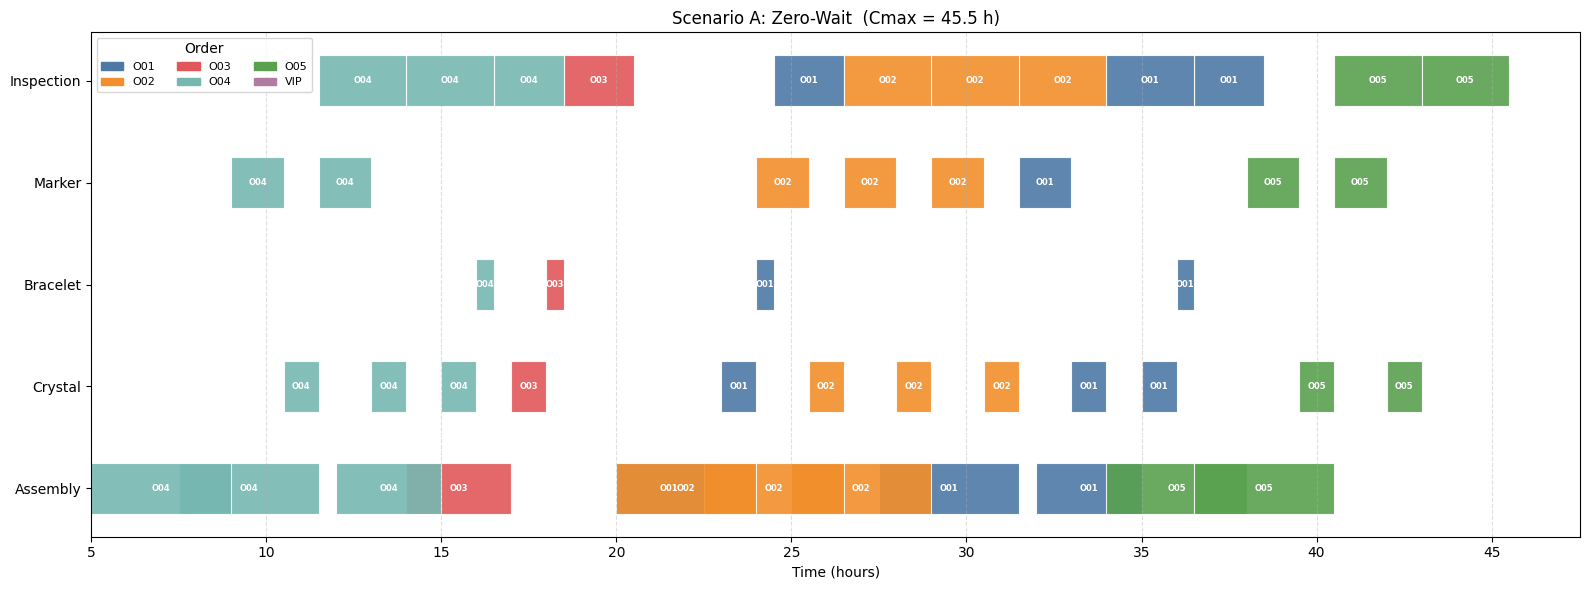


── Interpretation ──
Zero-wait forces each watch to move immediately to the next station.
This eliminates buffer inventory but may block upstream stations.
Makespan change: 0.0 h — no impact: schedule had no natural waiting.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO A: Zero-Wait Policy
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  SCENARIO A — ZERO-WAIT POLICY")
print(f"{'='*60}")

df_A, _, df_ord_A, cmax_A, _ = solve_schedule(base_jobs, zero_wait=True)

print(f"Cmax baseline: {cmax_base} h  →  Cmax zero-wait: {cmax_A} h  "
      f"(Delta = {round(cmax_A - cmax_base, 2)} h)")
print("\n── Order-Level KPIs (Scenario A) ──")
display(df_ord_A)
plot_gantt(df_A, title=f"Scenario A: Zero-Wait  (Cmax = {cmax_A} h)")
print("\n── Interpretation ──")
print("Zero-wait forces each watch to move immediately to the next station.")
print("This eliminates buffer inventory but may block upstream stations.")
print(f"Makespan change: {round(cmax_A - cmax_base, 2)} h — "
      + ("makespan grows: forced flow blocks upstream ops."
         if cmax_A > cmax_base else "no impact: schedule had no natural waiting."))

##Scenario B


  SCENARIO B — CLEANING BETWEEN MODELS (0.5h)
Cmax baseline: 45.5 h  →  Cmax with cleaning: 45.5 h  (Delta = 0.0 h)

── Order-Level KPIs (Scenario B) ──


,Order,Due,Completion,Tardiness
0,O01,40,40,0
1,O02,40,38,0
2,O03,30,25,0
3,O04,40,23,0
4,O05,50,46,0


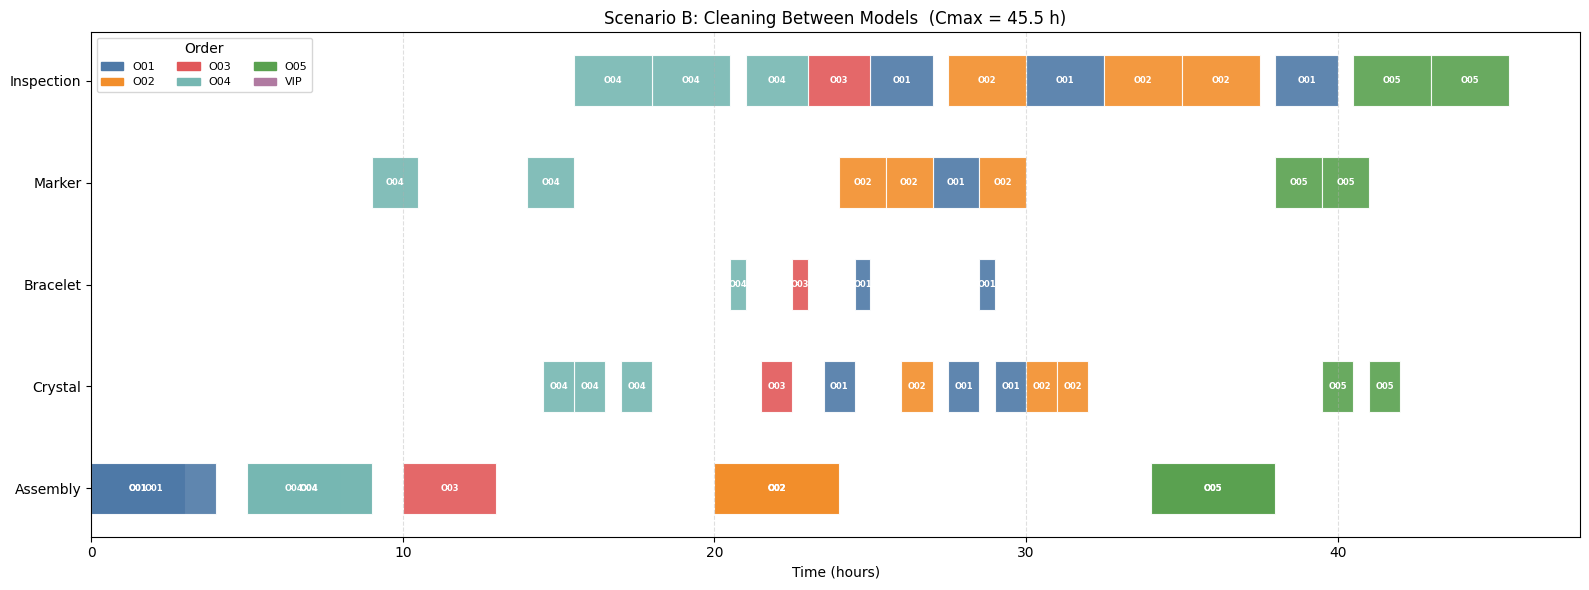


── Interpretation ──
The optimiser batches same-type watches on each station to minimise
cleaning events. Heritage and Chronos runs are naturally grouped,
reducing total cleaning overhead vs a random sequencing.


In [25]:

# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO B: Cleaning Between Different Watch Types (0.5h)
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  SCENARIO B — CLEANING BETWEEN MODELS (0.5h)")
print(f"{'='*60}")

df_B, _, df_ord_B, cmax_B, _ = solve_schedule(base_jobs, cleaning=True)

print(f"Cmax baseline: {cmax_base} h  →  Cmax with cleaning: {cmax_B} h  "
      f"(Delta = {round(cmax_B - cmax_base, 2)} h)")
print("\n── Order-Level KPIs (Scenario B) ──")
display(df_ord_B)
plot_gantt(df_B, title=f"Scenario B: Cleaning Between Models  (Cmax = {cmax_B} h)")
print("\n── Interpretation ──")
print("The optimiser batches same-type watches on each station to minimise")
print("cleaning events. Heritage and Chronos runs are naturally grouped,")
print("reducing total cleaning overhead vs a random sequencing.")


##Scenario C


  SCENARIO C — CRYSTAL FITTING BREAKDOWN (hrs 30-46)
Cmax baseline: 45.5 h  ->  Cmax with breakdown: 52.0 h  (Delta = 6.5 h)

── Order-Level KPIs (Scenario C) ──


,Order,Due,Completion,Tardiness
0,O01,40,36,0
1,O02,40,39,0
2,O03,30,19,0
3,O04,40,23,0
4,O05,50,52,2



Tardy orders: ['O05']


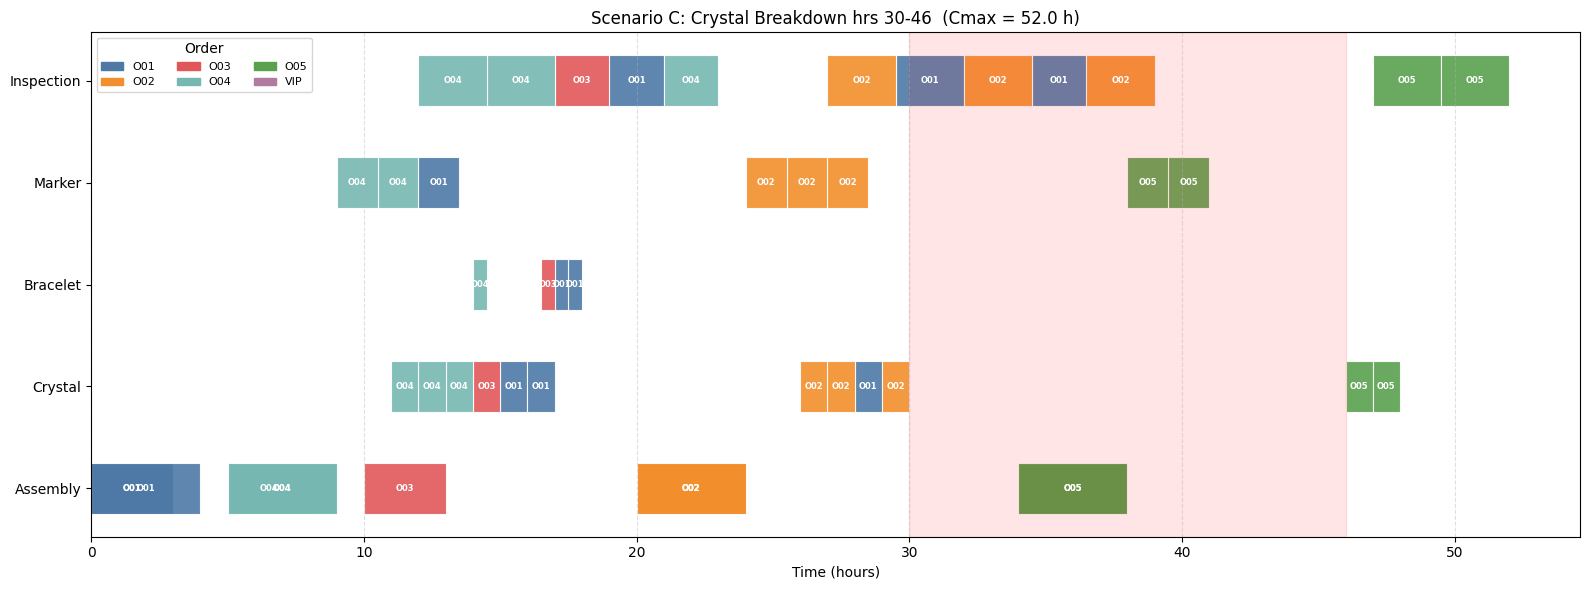


── Mitigation strategies ──
1. Front-load Crystal ops: complete all Crystal tasks before hour 30.
2. Redundancy: maintain a backup Crystal station for peak periods.
3. Priority re-sequencing: finish high-priority Crystal ops first.


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO C: Crystal Fitting Breakdown (hours 30 to 46)
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  SCENARIO C — CRYSTAL FITTING BREAKDOWN (hrs 30-46)")
print(f"{'='*60}")

df_C, _, df_ord_C, cmax_C, _ = solve_schedule(base_jobs, crystal_breakdown=(30, 46))

print(f"Cmax baseline: {cmax_base} h  ->  Cmax with breakdown: {cmax_C} h  "
      f"(Delta = {round(cmax_C - cmax_base, 2)} h)")
print("\n── Order-Level KPIs (Scenario C) ──")
display(df_ord_C)
tardy_C = df_ord_C[df_ord_C["Tardiness"] > 0]
if len(tardy_C) > 0:
    print(f"\nTardy orders: {list(tardy_C['Order'])}")
else:
    print("\nNo tardy orders — optimiser shifted Crystal ops before breakdown.")
plot_gantt(df_C, title=f"Scenario C: Crystal Breakdown hrs 30-46  (Cmax = {cmax_C} h)",
           crystal_breakdown=(30, 46))
print("\n── Mitigation strategies ──")
print("1. Front-load Crystal ops: complete all Crystal tasks before hour 30.")
print("2. Redundancy: maintain a backup Crystal station for peak periods.")
print("3. Priority re-sequencing: finish high-priority Crystal ops first.")

##Scenario D



  SCENARIO D — LAST-MINUTE VIP ORDER (released hr 20)
Cmax baseline: 45.5 h  ->  Cmax with VIP: 45.5 h  (Delta = 0.0 h)

── Order-Level KPIs (Scenario D, original orders only) ──


,Order,Due,Completion,Tardiness
0,O01,40,38,0
1,O02,40,40,0
2,O03,30,26,0
3,O04,40,20,0
4,O05,50,46,0



VIP order completion: 23.5 h


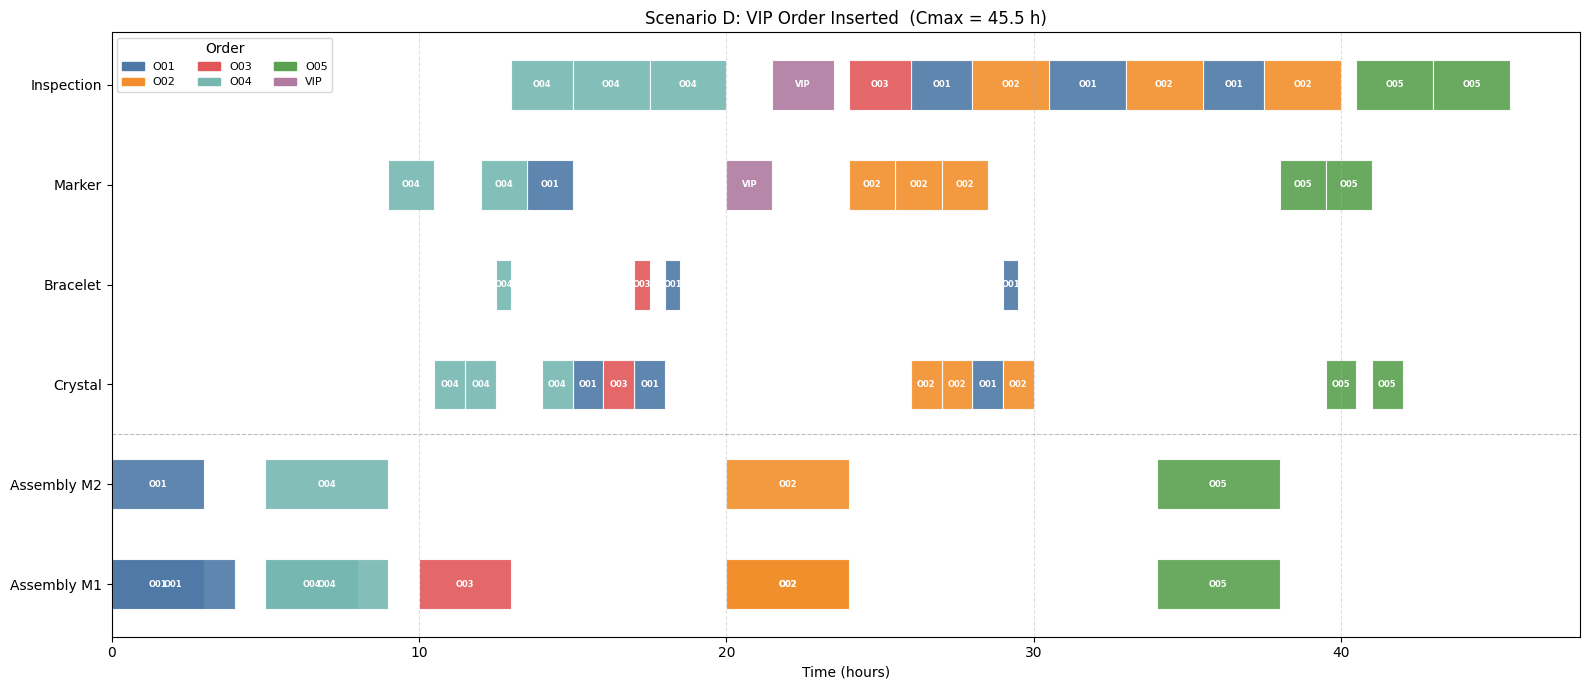


── Interpretation ──
The VIP job (priority 1, weight 3) is inserted at the earliest feasible
slot after its release at hour 20. Its high objective weight forces the
optimiser to prioritise it over lower-priority work.


In [32]:

# ═══════════════════════════════════════════════════════════════════════════════
# SCENARIO D: Last-Minute VIP Order (released hour 20)
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  SCENARIO D — LAST-MINUTE VIP ORDER (released hr 20)")
print(f"{'='*60}")

vip_job = {
    "job":      "VIP_Chronos_1",
    "order":    "VIP",
    "type":     "Chronos",
    "release":  20,
    "due":      24,
    "priority": 1,
    "routing":  [("Marker", 1.5), ("Inspection", 2.0)],
}

df_D, df_kpi_D, df_ord_D, cmax_D, _ = solve_schedule(base_jobs, vip_job=vip_job)

print(f"Cmax baseline: {cmax_base} h  ->  Cmax with VIP: {cmax_D} h  "
      f"(Delta = {round(cmax_D - cmax_base, 2)} h)")
print("\n── Order-Level KPIs (Scenario D, original orders only) ──")
display(df_ord_D[df_ord_D["Order"] != "VIP"])
vip_row = df_kpi_D[df_kpi_D["order"] == "VIP"]
print(f"\nVIP order completion: {vip_row['Cj'].values[0]} h")
plot_gantt(df_D, title=f"Scenario D: VIP Order Inserted  (Cmax = {cmax_D} h)")
print("\n── Interpretation ──")
print("The VIP job (priority 1, weight 3) is inserted at the earliest feasible")
print("slot after its release at hour 20. Its high objective weight forces the")
print("optimiser to prioritise it over lower-priority work.")


##Results



  SCENARIO COMPARISON SUMMARY


,Scenario,Cmax (h),Delta Cmax,Tardy Orders
0,Baseline,46,0,0
1,A: Zero-Wait,46,0,0
2,B: Cleaning,46,0,0
3,C: Breakdown,52,6,1
4,D: VIP,46,0,0


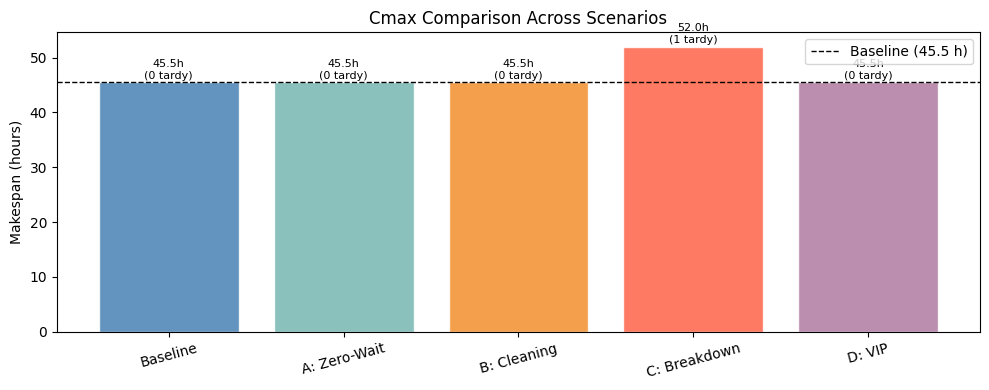

In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY COMPARISON
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  SCENARIO COMPARISON SUMMARY")
print(f"{'='*60}")

df_summary = pd.DataFrame({
    "Scenario":     ["Baseline", "A: Zero-Wait", "B: Cleaning", "C: Breakdown", "D: VIP"],
    "Cmax (h)":     [cmax_base, cmax_A, cmax_B, cmax_C, cmax_D],
    "Delta Cmax":   [0,
                     round(cmax_A - cmax_base, 2),
                     round(cmax_B - cmax_base, 2),
                     round(cmax_C - cmax_base, 2),
                     round(cmax_D - cmax_base, 2)],
    "Tardy Orders": [
        int(sum(df_ord_base["Tardiness"] > 0)),
        int(sum(df_ord_A["Tardiness"]    > 0)),
        int(sum(df_ord_B["Tardiness"]    > 0)),
        int(sum(df_ord_C["Tardiness"]    > 0)),
        int(sum(df_ord_D[df_ord_D["Order"] != "VIP"]["Tardiness"] > 0)),
    ],
})
display(df_summary)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["steelblue", "#76b7b2", "#f28e2b", "tomato", "#b07aa1"]
bars = ax.bar(df_summary["Scenario"], df_summary["Cmax (h)"],
              color=colors, alpha=0.85, edgecolor="white")
ax.axhline(cmax_base, color="black", linestyle="--", linewidth=1,
           label=f"Baseline ({cmax_base} h)")
for bar, v, t in zip(bars, df_summary["Cmax (h)"], df_summary["Tardy Orders"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f"{v}h\n({t} tardy)", ha="center", va="bottom", fontsize=8)
ax.set_ylabel("Makespan (hours)")
ax.set_title("Cmax Comparison Across Scenarios")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()